# PBA SE 2026 - Programa Alfabetiza Sergipe
## Relatório 2.1.1: Monitoramento da Aprendizagem e Rotina Pedagógica

**Autor:** Fabrício Camacho

**Objetivo:** Analisar o progresso de aprendizagem dos alfabetizandos e o cumprimento das metas operacionais estabelecidas no Termo de Referência relacionado ao resultado da **Atividade Formativa 1**, bem como a os **Relatórios Socioemocionais** elaborados pelos alfabetizadores.

**Data da Análise:** 26 de Maio de 2026.

## 1. Carregamento, Limpeza e Preparação dos Dados
### 1.1 Carregamento dos Dados
Aqui vamos carregar os dados previamente importandos de arquivo JSON em formato de snapshot e transferidos para um arquivo `.csv`, além de arquivos `.xlsx` retirados da plataforma de monitoramento da FGV. Os dados foram consultados  através de snapshot, garantindo que as informações extraídas do JSON permaneçam os mesmos daqueles extraídos no dia da análise, evitando mudanças futuras dos dados que possam ocorrer no decorrer do programa.

In [315]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os
import geopandas as gpd
from sklearn.cluster import KMeans
import math
from IPython.display import display
import json

# Importando arquivos separados
df_pedagogico = pd.read_csv(
    'data_files/public_data/dados_pedagogicos_26052026.csv', encoding='utf-8-sig')
df_turmas = pd.read_excel(
    'data_files/public_data/turmas_26052026.xlsx')
df_relatorios_formativa_1 = pd.read_excel(
    'data_files/public_data/relatorios_turmas_formativa_1_26052026.xlsx')

# Criando diretório para salvar gráficos para relatório
dir_graficos = 'graficos_relatorio_2.1.1'
if not os.path.exists(dir_graficos):
    os.makedirs(dir_graficos)
    
# Garantindo cores de gráficos de acordo com paleta estabelecida
cores_pba = ["#005088", "#FFBB00", "#00843D", "#333333"]

# Imprimindo dados
print("-"*100)
print("df_pedagogico:")
print(df_pedagogico.info())
display(df_pedagogico.head())

print("-"*100)
print("df_turmas:")
print(df_turmas.info())
display(df_turmas.head())

print("-"*100)
print("df_relatorios_formativa_1:")
print(df_relatorios_formativa_1.info())
display(df_relatorios_formativa_1.head())


----------------------------------------------------------------------------------------------------
df_pedagogico:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3670 entries, 0 to 3669
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpf                         3670 non-null   object 
 1   alfabetizando               3670 non-null   object 
 2   turma                       3670 non-null   object 
 3   status_alfabetizando        3670 non-null   object 
 4   dt_inicio_turma             3670 non-null   object 
 5   alfabetizador               3670 non-null   object 
 6   coordenador                 3670 non-null   object 
 7   qtd_aulas_dadas_turma       3670 non-null   int64  
 8   qtd_presenca_alfabetizando  3459 non-null   float64
 9   diag_entr_q1                2771 non-null   float64
 10  diag_entr_q2                2771 non-null   float64
 11  diag_entr_q3                277

,cpf,alfabetizando,turma,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,qtd_presenca_alfabetizando,diag_entr_q1,...,socio_said_q1,socio_said_q2,socio_said_q3,socio_said_q4,socio_said_q5,socio_said_q6,socio_said_q7,socio_said_q8,socio_said_q9,socio_said_result
0,105.473.268-07,Dr. Antony Nogueira,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,17,15.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,723.451.698-00,Dr. Rhavi Moura,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,17,10.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,190.856.423-70,Bella Sousa,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,17,16.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,027.168.345-71,Théo Pimenta,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,17,12.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,609.712.853-30,Gael Henrique das Neves,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,17,16.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------
df_turmas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Turma                   139 non-null    object 
 1   Escola                  139 non-null    object 
 2   Município               139 non-null    object 
 3   Qtd. alfabetizandos     139 non-null    int64  
 4   Coordenador             139 non-null    object 
 5   Alfabetizador           139 non-null    object 
 6   Data início             139 non-null    object 
 7   Data prevista de fim    139 non-null    object 
 8   Situação da turma       139 non-null    object 
 9   Data situação da turma  0 non-null      float64
 10  Data fim (máx.)         139 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 12.1+ KB
None


,Turma,Escola,Município,Qtd. alfabetizandos,Coordenador,Alfabetizador,Data início,Data prevista de fim,Situação da turma,Data situação da turma,Data fim (máx.)
0,TURMA-P0000206-0002,AOOS ASSOCIACAO OTAVIANO OLIVEIRA DE SOUZA,RIACHÃO DO DANTAS,20,Alexandre Pinto,Juliana Dias,27/04/2026,13/08/2026,Em funcionamento,NaN,14/08/2026
1,TURMA-P0000236-0001,ASSENTAMENTO EMÍLIA MARIA,SÃO CRISTÓVÃO,24,Luiz Otávio Vasconcelos,Ana Laura Castro,27/04/2026,12/08/2026,Em funcionamento,NaN,14/08/2026
2,TURMA-P0000248-0001,ASSENTAMENTO GIRASSOL,PORTO DA FOLHA,24,Ana Sophia Aragão,Camila Correia,27/04/2026,12/08/2026,Em funcionamento,NaN,14/08/2026
3,TURMA-P0000243-0001,ASSOCIAÇÃO ATLÉTICA DE ITABAIANA,ITABAIANA,24,Josué Leão,Bella Costa,27/04/2026,23/07/2026,Em funcionamento,NaN,14/08/2026
4,TURMA-P0000227-0002,ASSOCIAÇÃO - CENTRO COMUNITÁRIO CHE GUEVARA,LAGARTO,22,Heloisa Azevedo,Ana Lívia Macedo,27/04/2026,10/08/2026,Em funcionamento,NaN,14/08/2026


----------------------------------------------------------------------------------------------------
df_relatorios_formativa_1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   ALFABETIZADOR                                                                          131 non-null    object 
 1   TURMA                                                                                  131 non-null    object 
 2   DATA DE LANÇAMENTO                                                                     131 non-null    object 
 3   Consolidação e análise dos dados realizadas por mecanismos de Inteligência Artificial  84 non-null     object 
 4   Observações do alfabetizador                                       

,ALFABETIZADOR,TURMA,DATA DE LANÇAMENTO,Consolidação e análise dos dados realizadas por mecanismos de Inteligência Artificial,Observações do alfabetizador
0,Ana Vitória Castro,TURMA-P0000247-0001,22/05/2026,sdf sdfsd fsdfsdfsdf,NaN
1,Sr. João Guilherme das Neves,TURMA-28009398-0012,22/05/2026,Obs. Os alunos estão se desenvolvendo aos pouc...,NaN
2,Sr. Yuri da Luz,TURMA-28007158-0002,19/05/2026,Em alguns observo bastante dificuldades em ent...,NaN
3,Srta. Letícia Fernandes,TURMA-P0000241-0001,20/05/2026,O que venho observando é a melhoria nas partic...,NaN
4,Dr. Pedro Lucas Fernandes,TURMA-28029372-0002,21/05/2026,NaN,NaN


**Observação:** É possível notar que os dados apresentam algumas características que precisam ser alteradas. Seguem elas:
- **Nome das colunas de arquivos XLSX:** Dados oriundos de arquivos extraídos da plataforma de monitoramento da FGV DGPE estão fora do padrão snake case e precisa ser alterados;
- **Dados tipo "object" de algumas colunas:** As colunas *"status_alfabetizando", "diag_entr_result", "socio_entr_result", "forma_1_result", "forma_2_result", "forma_3_result", "forma_4_result", "diag_said_result"* e *"socio_said_result"* em `df_pedagógico` apresentam dados categóricos. Por esse motivo, precisamos alterar o tipo de dado principalemnte para poupar espaço em memória durante a análise;
- **Dados com data:** A coluna "dt_inicio_turma" em *"df_pedagogico", "Data início", "Data prevista de fim", "Data situação da turma"* e *"Data fim (máx.)"* em `df_turmas`; e *"DATA DE LANÇAMENTO"* em `df_relatorios_diagnostica` apresentam dados de data e hora e precisam ser transformados em tal formato.
- **Resultados das Atividades:** Os resultados das atividades apresentam texto longo. Vamos criar uma coluna a mais para cada resultado contendo somente o nível em que o alfabetizando foi classificado ou um texto mais resumido.
- **Turma Modelo:** A turma **TURMA-P0000247-0001** foi criada para teste e possui dados falsos. Todos os dados dela precisam ser retirados para limpar a análise;
- **Alunos Evadidos:** A base de dados contém alfabetizandos que evadiram e não apresentam resultados de atividades. Dessa maneira, alfabetizandos com status **"EVADIDO"** na coluna *"status_alfabetizando"* não serão considerados na análise.

### 1.2 Preparação de Dados
Aqui vamos fazer a limpeza e preparação dos dados da seguinte forma:
- Alterar nome das colunas para padrão snake case;
- Tranformar dados tipo *object* em dados categóricos ou de data de acordo com o observado anteriormente;
- Resumir textos de resultados das atividades para melhor visualização;
- Criar colunas de resultados das atividades somente com o valor do Nível (N1, N2, N3 ou N4).


In [316]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    # Converte para minúsculo
    column_name = column_name.lower()
    
    # Remove acentos (Mantenha sua lógica ou use normalize)
    replacements = {
        'é': 'e', 'ã': 'a', 'ç': 'c', 'í': 'i', 'ó': 'o', 
        'ú': 'u', 'á': 'a', 'ê': 'e', 'ô': 'o', 'õ': 'o'
    }
    for char, replacement in replacements.items():
        column_name = column_name.replace(char, replacement)
    
    # Remove parênteses e pontos
    column_name = re.sub(r'[().]', '', column_name)
    
    # Substitui qualquer tipo de espaço por underscore
    # O \s+ pega um ou mais espaços de qualquer tipo (incluindo \xa0)
    column_name = re.sub(r'\s+', '_', column_name)
    
    return column_name.strip('_')

# Aplica a função to_snake_case aos nomes das colunas
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_relatorios_formativa_1.columns = [to_snake_case(col) for col in df_relatorios_formativa_1.columns]

# Verificando resultados
print(df_turmas.columns)
print(df_relatorios_formativa_1.columns)


Index(['turma', 'escola', 'municipio', 'qtd_alfabetizandos', 'coordenador',
       'alfabetizador', 'data_inicio', 'data_prevista_de_fim',
       'situacao_da_turma', 'data_situacao_da_turma', 'data_fim_max'],
      dtype='object')
Index(['alfabetizador', 'turma', 'data_de_lancamento',
       'consolidacao_e_analise_dos_dados_realizadas_por_mecanismos_de_inteligencia_artificial',
       'observacoes_do_alfabetizador'],
      dtype='object')


In [317]:
# Transformando tipo de dados object em dados mais representativos (categorias e datas)
# Definindo colunas categóricas para df_pedagogico
cols_categoricas = [
    "status_alfabetizando", "diag_entr_result",
    "socio_entr_q1", "socio_entr_q2", "socio_entr_q3", "socio_entr_q4", 
    "socio_entr_q5", "socio_entr_q6", "socio_entr_q7",
    "forma_1_result", "forma_2_result", "forma_3_result", 
    "forma_4_result", "diag_said_result", 
    "socio_said_q1", "socio_said_q2", "socio_said_q3", "socio_said_q4", 
    "socio_said_q5", "socio_said_q6", "socio_said_q7"
]

def transformar_dados_pba(df_pedag, df_turmas, df_diag=None):
    """
    Realiza a limpeza e transformação de tipos para o projeto Alfabetiza Sergipe.
    """
    # Transformação de Categóricos (df_pedagogico)
    for col in cols_categoricas:
        if col in df_pedag.columns:
            df_pedag[col] = df_pedag[col].astype('category')
            
    # Transformação de Datas (df_pedagogico)
    if 'dt_inicio_turma' in df_pedag.columns:
        df_pedag['dt_inicio_turma'] = pd.to_datetime(df_pedag['dt_inicio_turma'], dayfirst=True, errors='coerce')
        
    # Transformação de Datas (df_turmas)
    cols_datas_turmas = ["data_inicio", "data_prevista_de_fim", "data_situacao_da_turma", "data_fim_max"]
    
    for col in cols_datas_turmas:
        if col in df_turmas.columns:
            df_turmas[col] = pd.to_datetime(df_turmas[col], dayfirst=True, errors='coerce')
            
    # Transformação de Datas (df_relatorios_formativa_1 - se existir)
    if df_diag is not None and "DATA DE LANÇAMENTO" in df_diag.columns:
        df_diag["data_de_lancamento"] = pd.to_datetime(df_diag["data_de_lancamento"], dayfirst=True, errors='coerce')
        
    print("Transformação concluída com sucesso!")
    return df_pedag, df_turmas, df_diag

# Aplicando a função
df_pedagogico, df_turmas, df_relatorios_formativa_1 = transformar_dados_pba(df_pedagogico, df_turmas, df_relatorios_formativa_1)

# Checando resultados
print(df_pedagogico.info())
print(df_turmas.info())
print(df_relatorios_formativa_1.info())


Transformação concluída com sucesso!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3670 entries, 0 to 3669
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         3670 non-null   object        
 1   alfabetizando               3670 non-null   object        
 2   turma                       3670 non-null   object        
 3   status_alfabetizando        3670 non-null   category      
 4   dt_inicio_turma             3670 non-null   datetime64[ns]
 5   alfabetizador               3670 non-null   object        
 6   coordenador                 3670 non-null   object        
 7   qtd_aulas_dadas_turma       3670 non-null   int64         
 8   qtd_presenca_alfabetizando  3459 non-null   float64       
 9   diag_entr_q1                2771 non-null   float64       
 10  diag_entr_q2                2771 non-null   float64       
 11  diag_entr_q3       

In [318]:
# Mapeamento de variáveis categóricas para simplificar visualizações
mapeamento_textos = {
    'Demonstra motivação constante e desejo de continuar estudando': 'Demosntra motivação', 
    'Demonstra interesse, mas com oscilações': 'Demonstra interesse', 
    'Demonstra desmotivação ou desejo de interromper': 'Demonstra desmotivação', 
    'São frequentes e pontuais': 'Frequentes e pontuais', 
    'Frequência regular sem nenhuma falta': 'Frequência sem faltas', 
    'Frequência regular com algumas faltas': 'Frequência com faltas', 
    'Realiza com alguma ajuda': 'Realiza com ajuda', 
    'Realiza com autonomia na maioria das situações': 'Realiza com autonomia',
    'Depende de ajuda constante': 'Depende de ajuda', 
    'Tenta com apoio e incentivo': 'Tenta com apoio',
    'Tenta com iniciativa própria': 'Tenta com iniciativa',
    'Demonstra insegurança e evita tentar': 'Demonstra insegurança', 
    'Persiste e aceita o erro como parte da aprendizagem': 'Persiste e aceita o erro',
    'Persiste, mas demonstra frustração': 'Persiste com frustração',
    'Desiste facilmente': 'Desiste facilmente', 
    'Participa ativamente e coopera com os colegas': 'Participa e coopera',
    'Participa quando estimulado(a)': 'Participa quando estimulado(a)',
    'Evita interações': 'Evita interações', 
    'Reconhece claramente e relata usos práticos': 'Reconhece claramente',
    'Reconhece em algumas situações': 'Reconhece algumas vezes',
    'Não reconhece': 'Não reconhece', 
    'N1 | Não reconhece as letras do alfabeto': 'N1',
    'N2 | Lê e registra algumas letras com ajuda, sem relação entre fala e escrita': 'N2',
    'N3 | Reconhece algumas letras do alfabeto': 'N3',
    'N4 | Identifica o número de sílabas de palavras com apoio': 'N4', 
    'N1 | Atenção à escuta e reconhecimento inicial de letras': 'N1', 
    'N2 | Reconhece letras e sílabas com apoio': 'N2',
    'N3 | Identifica sílabas, sem relação letra–som': 'N3',
    'N4 | Reconhece sílabas, sem leitura de palavras': 'N4'
}

# Criar a novas colunas resumidas para cada coluna categórica usando o .map()
for coluna in cols_categoricas:
    df_pedagogico[coluna + '_resum'] = df_pedagogico[coluna].map(mapeamento_textos)

# Transformar em tipo Categórico (ordenado) somente as colunas com níveis
# Isso é importante para que em gráficos o N1 venha antes do N2, etc.
niveis_ordenados = ['N1', 'N2', 'N3', 'N4']
colunas_niveis = ['diag_entr_result_resum', 'forma_1_result_resum', 'forma_2_result_resum', 'forma_3_result_resum', 'forma_4_result_resum', 'diag_said_result_resum']

for coluna in colunas_niveis:
    df_pedagogico[coluna] = pd.Categorical(
        df_pedagogico[coluna], 
        categories=niveis_ordenados, 
        ordered=True
    )

# Removemos colchetes, aspas duplas, aspas simples da coluna socio_entr_q9 e depois dividimos por vírgula
# 1. Criamos uma função inteligente para transformar o texto em uma lista real do Python
def extrair_lista_q9(valor):
    # Se o valor for vazio (NaN), retorna lista vazia
    if pd.isna(valor):
        return []
    
    # Se por acaso já for uma lista, ótimo, apenas retorna
    if isinstance(valor, list):
        return valor
    
    # Limpa espaços em branco nas bordas
    texto = str(valor).strip()
    
    if not texto or texto.lower() == 'nan':
        return []
    
    try:
        # O json.loads pega '["Falta de confian\u00e7a em si"]' e transforma perfeitamente na lista ['Falta de confiança em si']
        # Caso o CSV tenha duplicado aspas (ex: "[""...""]"), corrigimos antes
        texto = texto.replace('""', '"')
        lista = json.loads(texto)
        
        # Retorna a lista garantindo que não há itens vazios soltos
        return [str(item).strip() for item in lista if str(item).strip()]
    except:
        # PLANO B: Se o json falhar por algum caractere estranho, limpamos na mão
        limpo = texto.replace('[', '').replace(']', '').replace('"', '').replace("'", "")
        return [item.strip() for item in limpo.split(',') if item.strip()]
    
# 2. Aplicamos a nossa função na coluna para criar a coluna com as listas reais
df_pedagogico['socio_entr_q8_resum'] = df_pedagogico['socio_entr_q9'].apply(extrair_lista_q9)

# Verificando os tipos de dados e informações das colunas
print(df_pedagogico.info())
display(df_pedagogico.head())
display(df_pedagogico[['socio_entr_q9', 'socio_entr_q8_resum']].head())
print(df_pedagogico['socio_entr_q8_resum'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3670 entries, 0 to 3669
Data columns (total 87 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         3670 non-null   object        
 1   alfabetizando               3670 non-null   object        
 2   turma                       3670 non-null   object        
 3   status_alfabetizando        3670 non-null   category      
 4   dt_inicio_turma             3670 non-null   datetime64[ns]
 5   alfabetizador               3670 non-null   object        
 6   coordenador                 3670 non-null   object        
 7   qtd_aulas_dadas_turma       3670 non-null   int64         
 8   qtd_presenca_alfabetizando  3459 non-null   float64       
 9   diag_entr_q1                2771 non-null   float64       
 10  diag_entr_q2                2771 non-null   float64       
 11  diag_entr_q3                2771 non-null   float64     

,cpf,alfabetizando,turma,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,qtd_presenca_alfabetizando,diag_entr_q1,...,forma_4_result_resum,diag_said_result_resum,socio_said_q1_resum,socio_said_q2_resum,socio_said_q3_resum,socio_said_q4_resum,socio_said_q5_resum,socio_said_q6_resum,socio_said_q7_resum,socio_entr_q8_resum
0,105.473.268-07,Dr. Antony Nogueira,TURMA-28002970-0001,CURSANDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,17,15.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Dificuldade ao falar]
1,723.451.698-00,Dr. Rhavi Moura,TURMA-28002970-0001,CURSANDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,17,10.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Habilidades motoras]
2,190.856.423-70,Bella Sousa,TURMA-28002970-0001,CURSANDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,17,16.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Dificuldade ao falar]
3,027.168.345-71,Théo Pimenta,TURMA-28002970-0001,CURSANDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,17,12.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Dificuldade ao falar]
4,609.712.853-30,Gael Henrique das Neves,TURMA-28002970-0001,CURSANDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,17,16.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Dificuldade ao falar]


,socio_entr_q9,socio_entr_q8_resum
0,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
1,"[""Habilidades motoras""]",[Habilidades motoras]
2,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
3,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
4,"[""Dificuldade ao falar""]",[Dificuldade ao falar]


socio_entr_q8_resum
[]                                                                                                                                                                                                                           1454
[Dificuldade ao falar]                                                                                                                                                                                                        287
[Falta de confiança em si]                                                                                                                                                                                                    241
[Habilidades motoras]                                                                                                                                                                                                         177
[Necessidade de maior flexibilidade nos horários]                           

### 1.3 Limpeza e Organização de Dados
Aqui retiraremos alguns dados e adicionar informações para que a análise ocorra corretamente. Os seguintes dados serão retirados:
- Dados da turma **TURMA-P0000247-0001**, que foi criada para teste e não apresenta dados reais;
- Dados de alfabetizandos com status **EVADIDO**;
- Adicionar informação de município ao `df_pedagogico`, juntando com as informações de `df_turma`;
- Retirar valores vazios de alfabetizandos sem resultados


In [319]:
# Verificando o tamanho antes da filtragem
print(f"Registros antes da filtragem: {len(df_pedagogico)}")

# 2. Aplicando os filtros
# Filtro: Turma diferente de 'TURMA-P0000247-0001' E Status diferente de 'EVADIDO'
def filtrar_turmas(df):
    """
    Filtra o DataFrame verificando se as colunas necessárias existem.
    """
    # Criamos uma cópia para evitar o SettingWithCopyWarning
    df_resultado = df.copy()
    
    # 1. Verificação da coluna 'turma'
    if 'turma' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['turma'] != 'TURMA-P0000247-0001']
    else:
        print("Aviso: Coluna 'turma' não encontrada em. Filtro de turma não aplicado.")
    
    # 2. Verificação da coluna 'status_alfabetizando'
    if 'status_alfabetizando' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['status_alfabetizando'] != 'EVADIDO']
    else:
        print("Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.")
    
    return df_resultado

# Aplicando a função
df_pedagogico = filtrar_turmas(df_pedagogico)
df_turmas = filtrar_turmas(df_turmas)
df_relatorios_formativa_1 = filtrar_turmas(df_relatorios_formativa_1)

# 3. Verificando o tamanho após a filtragem
print(f"Registros após a filtragem: {len(df_pedagogico)}")

# 4. Validando se a turma ainda existe no dataset
check_turma = 'TURMA-P0000247-0001' in df_pedagogico['turma'].unique()
print(f"A turma TURMA-P0000247-0001 ainda está presente? {check_turma}")


Registros antes da filtragem: 3670
Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.
Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.
Registros após a filtragem: 2675
A turma TURMA-P0000247-0001 ainda está presente? False


In [320]:
# Adicionando informações de município aos dados pedagógicos de df_pedagogico
# Criando o DataFrame de referência apenas com as colunas necessárias
df_dados_turmas = df_turmas[['turma', 'municipio', 'escola']].drop_duplicates()

# Realizando o merge
# Unimos pela coluna 'turma' (df_pedagógico) e 'turma' (df_turmas)
df_pedagogico = pd.merge(
    df_pedagogico, 
    df_dados_turmas, 
    on='turma',  
    how='left'
)

# Retirando linhas de alfabetizandos sem resultados
df_pedagogico = df_pedagogico.dropna(subset=['diag_entr_result']).copy()

# Verificação: conferir se há alunos sem município atribuído
nas_municipio = df_pedagogico['municipio'].isna().sum()
print(f"Alunos sem município após o join: {nas_municipio}")

if nas_municipio > 0:
    print("Aviso: Existem turmas no pedagógico que não constam no cadastro de turmas.")


Alunos sem município após o join: 0


## 2. Análise da Avaliação Socioemocional de Entrada

Nesta seção, exploramos as respostas dadas ao questionário socioemocional aplicado no início do ciclo (questões 1 a 9). O objetivo é entender o contexto de motivação, frequência e apoio familiar dos alfabetizandos.
 
*Nota: Vamos observar que algumas questões podem não ter sido preenchidas ou aplicadas (como a q8, que se mostrou vazia na análise inicial dos dados).*

In [321]:
# Fazemos o "Explode": separa a lista criando uma linha para cada resposta dada
df_q8_explodido = df_pedagogico.explode('socio_entr_q8_resum')

# Removemos qualquer linha que tenha ficado vazia após o explode
df_q8_explodido = df_q8_explodido.dropna(subset=['socio_entr_q8_resum'])
df_q8_explodido = df_q8_explodido[df_q8_explodido['socio_entr_q8_resum'] != '']

# Contamos a frequência real de cada alternativa
contagem_q8 = df_q8_explodido['socio_entr_q8_resum'].value_counts()

print(contagem_q8)


socio_entr_q8_resum
Falta de confiança em si                           839
Dificuldade ao falar                               830
Habilidades motoras                                497
Dificuldade em manter a atenção                    366
Falta de incentivo                                 342
Necessidade de maior flexibilidade nos horários    283
Falta de apoio da família                          251
Dificuldade em ouvir o outro                       209
Questões de saúde                                  122
Horários incompatíveis para o estudo                96
Mudança de local das aulas                           5
Falta de material                                    3
Name: count, dtype: int64


Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/1_distribuicao_questoes_socioemocional_entrada.png


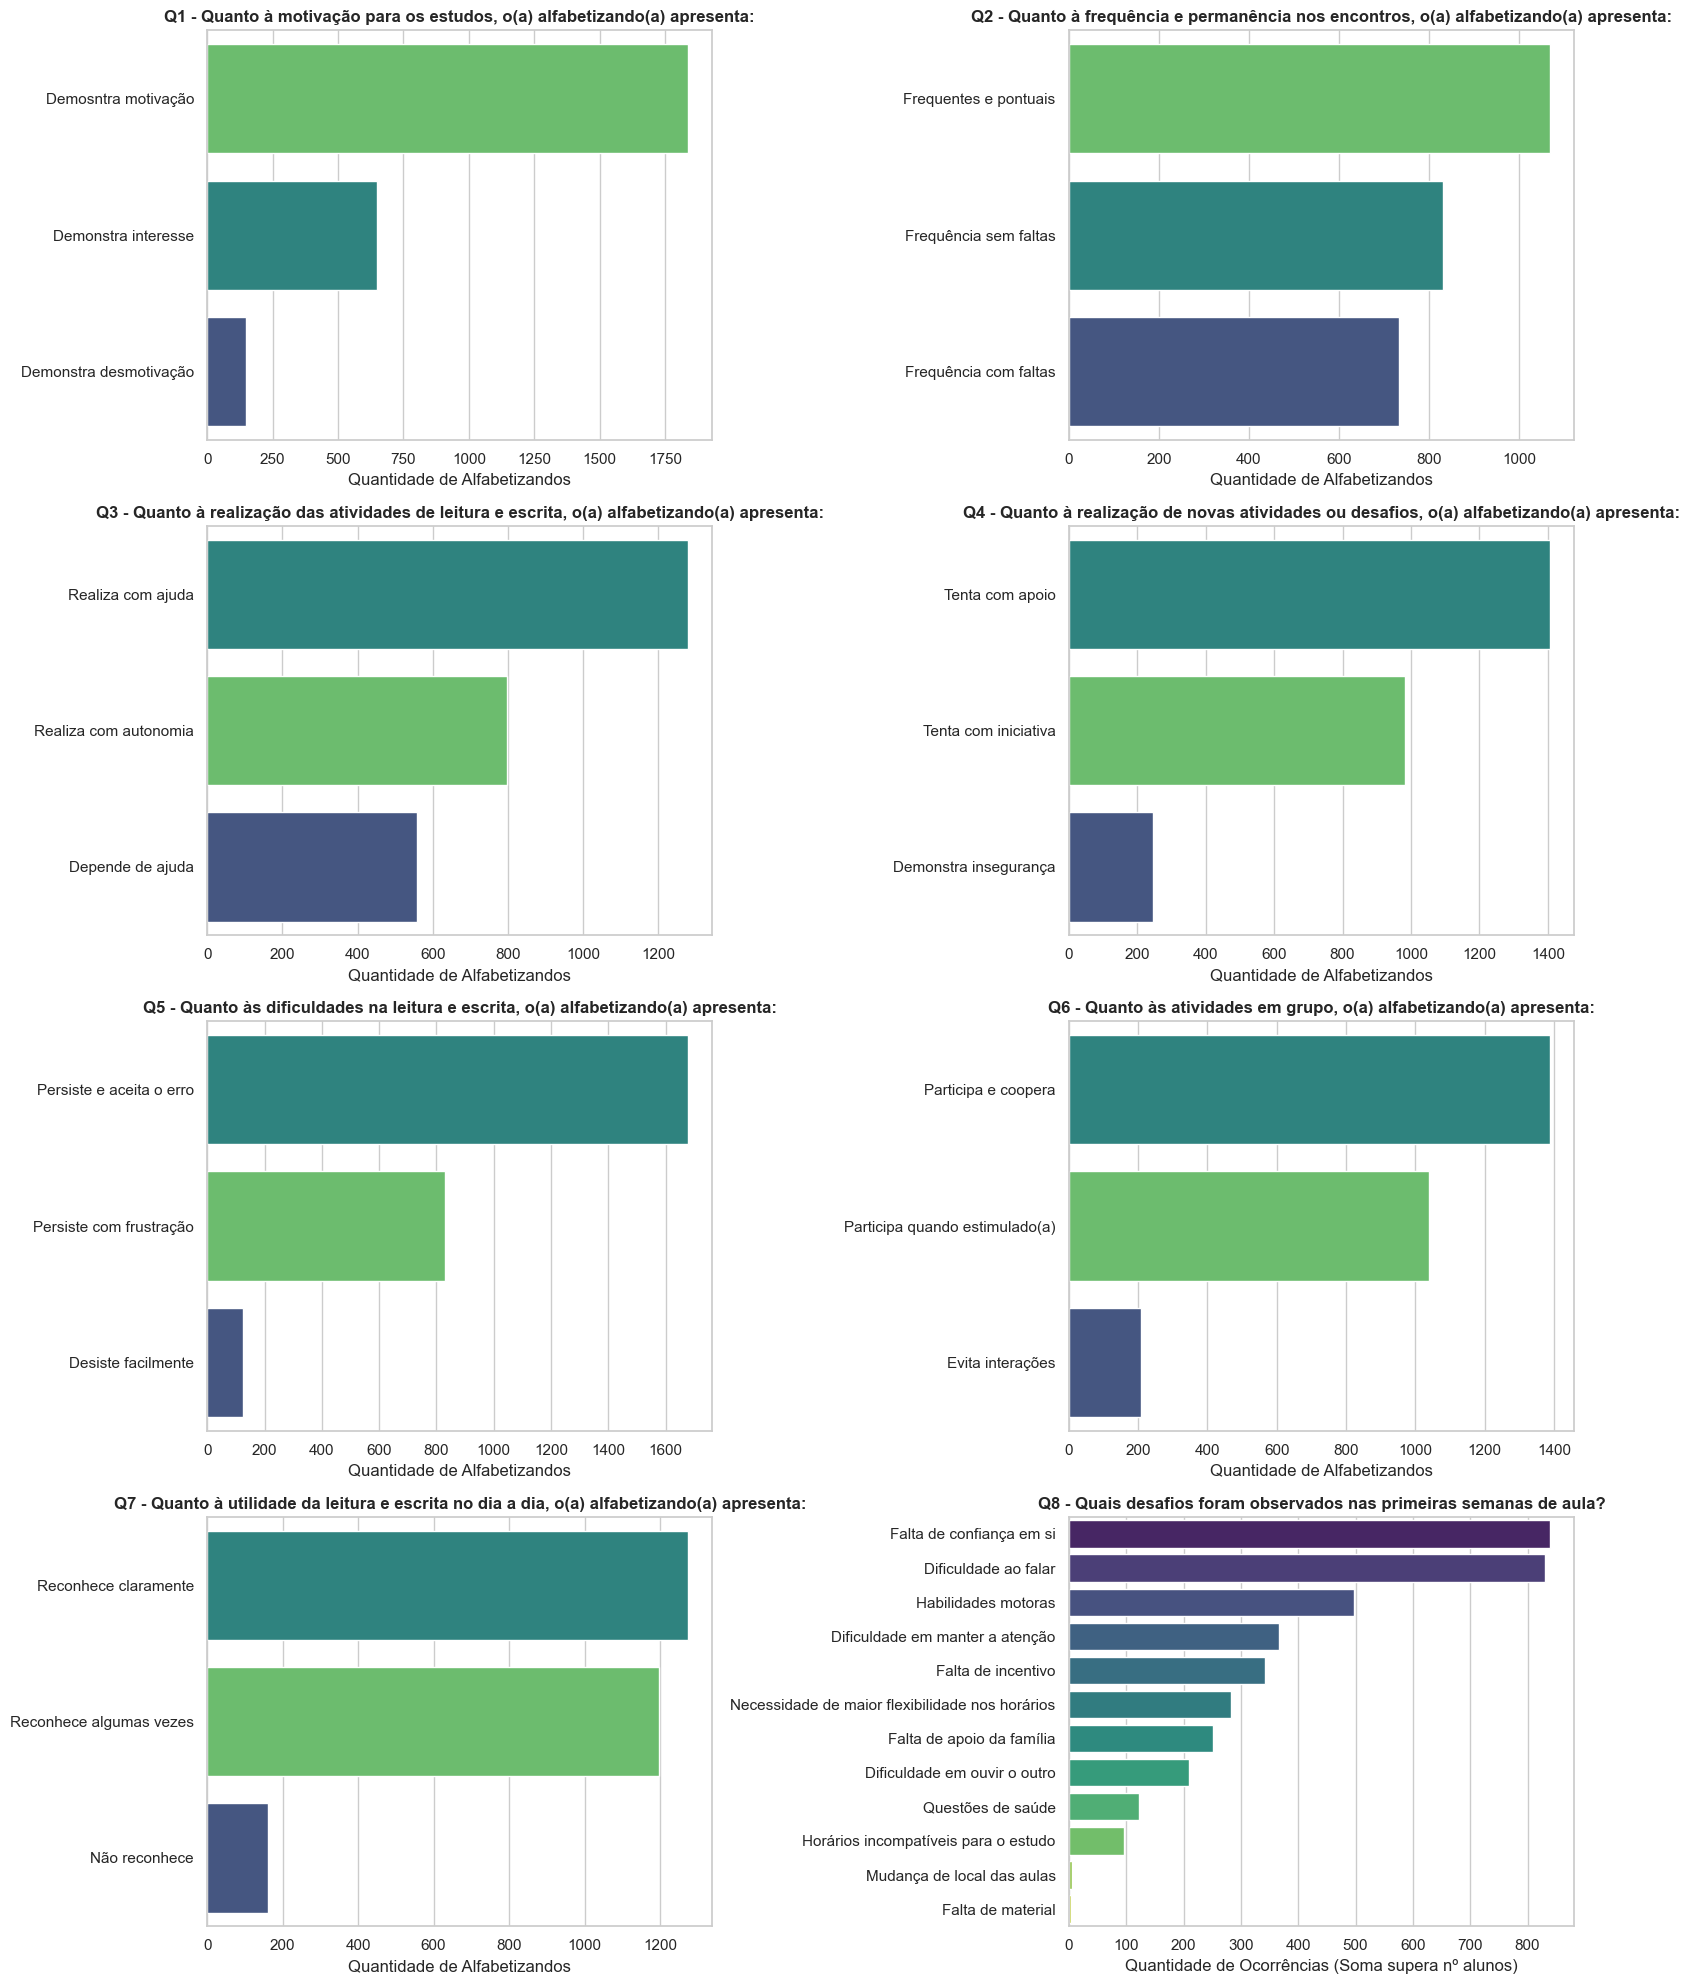

In [322]:
# Construindo dicionário com o enunciado de cada questão da Socioemocional
dicionario_questoes_socio = {
    'socio_entr_q1_resum': 'Q1 - Quanto à motivação para os estudos, o(a) alfabetizando(a) apresenta:',
    'socio_entr_q2_resum': 'Q2 - Quanto à frequência e permanência nos encontros, o(a) alfabetizando(a) apresenta:',
    'socio_entr_q3_resum': 'Q3 - Quanto à realização das atividades de leitura e escrita, o(a) alfabetizando(a) apresenta:',
    'socio_entr_q4_resum': 'Q4 - Quanto à realização de novas atividades ou desafios, o(a) alfabetizando(a) apresenta:',
    'socio_entr_q5_resum': 'Q5 - Quanto às dificuldades na leitura e escrita, o(a) alfabetizando(a) apresenta:',
    'socio_entr_q6_resum': 'Q6 - Quanto às atividades em grupo, o(a) alfabetizando(a) apresenta:',
    'socio_entr_q7_resum': 'Q7 - Quanto à utilidade da leitura e escrita no dia a dia, o(a) alfabetizando(a) apresenta:'
}

# Configurando estilo dos gráficos
sns.set_theme(style="whitegrid")

# Definindo as colunas (vamos pegar da 1 a 7 para o loop automático)
socio_cols = [f'socio_entr_q{i}_resum' for i in range(1, 8)]

# 1. Filtrar dinamicamente as colunas de 1 a 7 que possuem dados
cols_com_dados = [
    col for col in socio_cols 
    if col in df_pedagogico.columns and df_pedagogico[col].notna().sum() > 0
]

# 2. Criando a grade fixa de 4 linhas e 2 colunas (8 espaços totais)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# 3. Loop para desenhar as 7 primeiras questões
for i, col in enumerate(cols_com_dados):
    sns.countplot(
        y=col, 
        data=df_pedagogico, 
        order=df_pedagogico[col].value_counts().index, 
        palette='viridis', 
        hue=col,            
        legend=False,       
        ax=axes[i]
    )
    
    titulo = dicionario_questoes_socio.get(col, col)
    axes[i].set_title(titulo, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quantidade de Alfabetizandos')
    axes[i].set_ylabel('')

# =====================================================================
# 4. INSERINDO A QUESTÃO 8 NO ÚLTIMO ESPAÇO DA GRADE (Índice 7)
# =====================================================================
# ATENÇÃO: Substitua "socio_entr_q8_resum" abaixo pelo nome exato 
# da variável onde está a sua contagem (a Series que você colou acima).

variavel_contagem_q8 = contagem_q8.copy() 

sns.barplot(
    x=variavel_contagem_q8.values, 
    y=variavel_contagem_q8.index, 
    palette='viridis',
    hue=variavel_contagem_q8.index,
    legend=False,
    ax=axes[7] # axes[7] é o 8º e último quadrado!
)

# Configurando o título da Q8
titulo_q8 = 'Q8 - Quais desafios foram observados nas primeiras semanas de aula?'
axes[7].set_title(titulo_q8, fontsize=12, fontweight='bold')
axes[7].set_xlabel('Quantidade de Ocorrências (Soma supera nº alunos)')
axes[7].set_ylabel('')

# =====================================================================

# Ajuste do layout
plt.tight_layout()

# Salvando o gráfico
nome_grafico_1 = '1_distribuicao_questoes_socioemocional_entrada.png'
caminho_grafico_1 = os.path.join(dir_graficos, nome_grafico_1)

plt.savefig(caminho_grafico_1, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_1}")

plt.show()


## 3. Matriz de Relação: Nível Diagnóstico vs. Respostas Socioemocionais

Para entendermos se o nível de entrada do aluno (N1 a N4) tem relação com o seu perfil socioemocional, calculamos a proporção das respostas para cada questão dentro de cada nível de aprendizagem. 

As matrizes abaixo (Mapas de Calor de Contingência) mostram a percentagem de distribuição. Tons mais escuros indicam a resposta mais frequente para os alunos daquele nível específico.

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q1.png


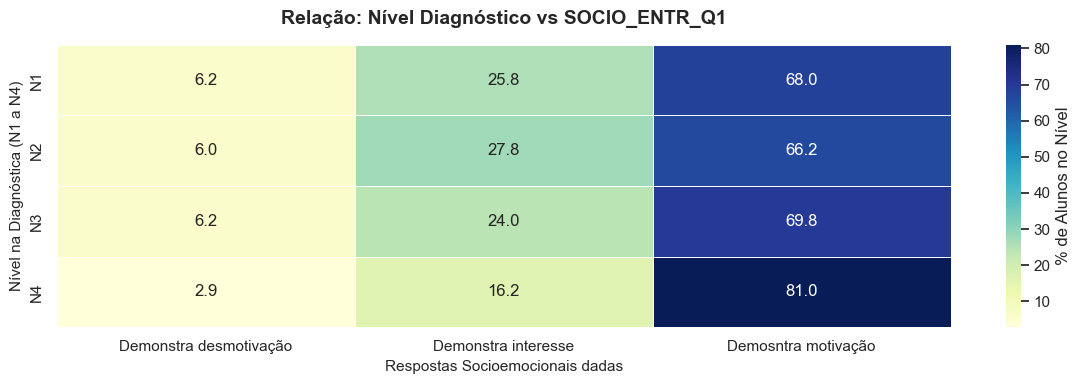

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q2.png


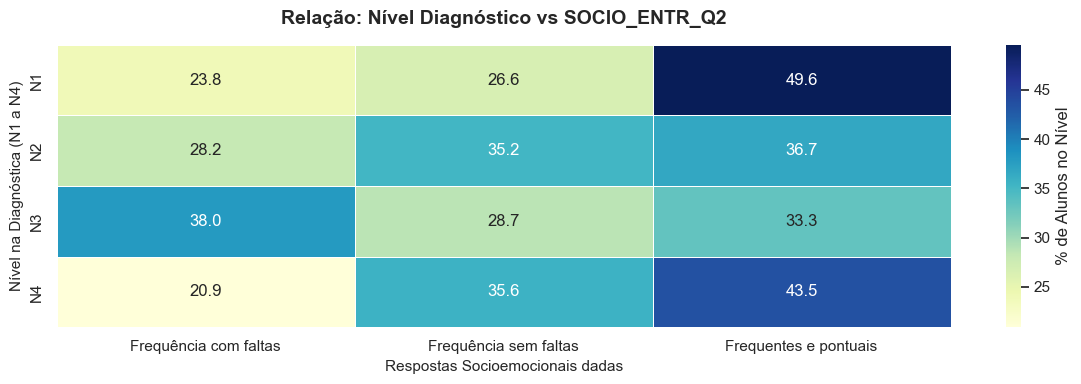

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q3.png


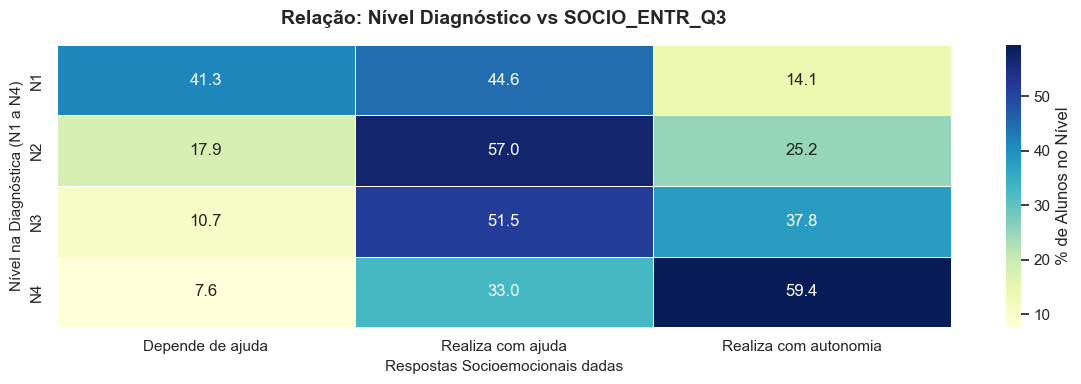

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q4.png


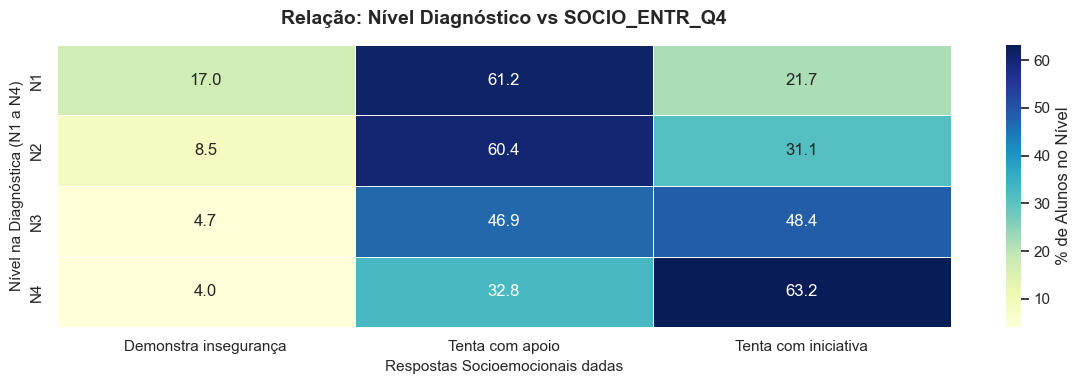

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q5.png


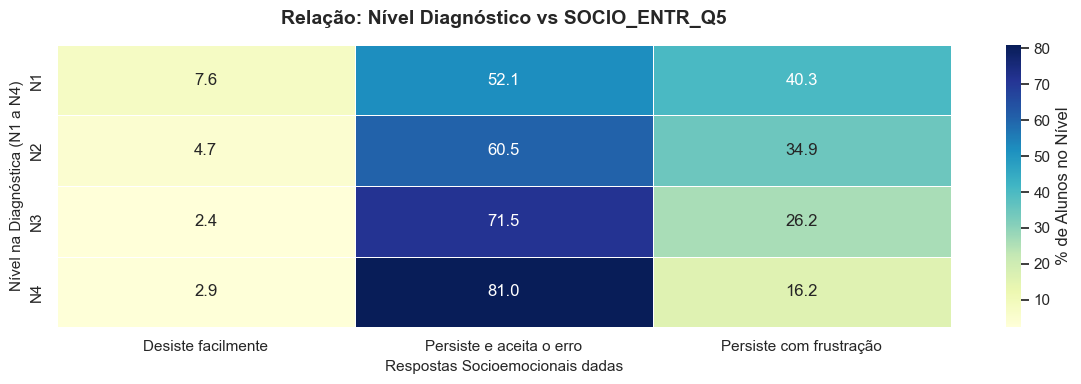

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q6.png


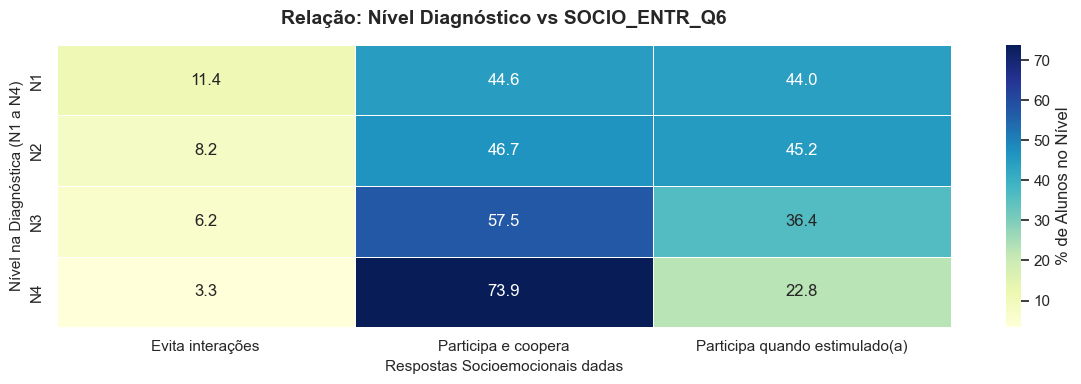

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/relacao_nivel_diagnostica_SOCIO_ENTR_Q7.png


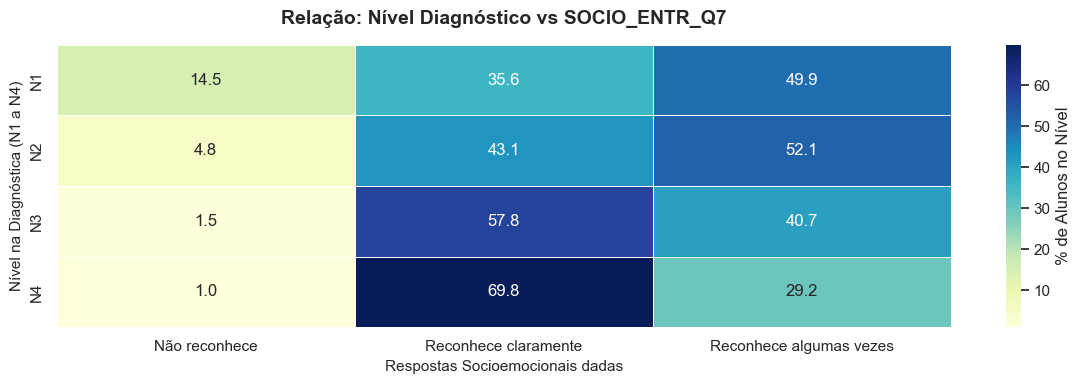

In [323]:
# 3. Gerar uma matriz (Heatmap) para cada questão socioemocional
for col in cols_com_dados:
    # Cria uma tabela cruzada com proporções calculadas por linha (normalize='index')
    crosstab_perc = pd.crosstab(
        df_pedagogico['diag_entr_result_resum'], 
        df_pedagogico[col], 
        normalize='index'
    ) * 100
    
    # Configurar o gráfico
    plt.figure(figsize=(12, 4))
    
    # Criar o mapa de calor
    sns.heatmap(
        crosstab_perc, 
        annot=True,          # Mostra os valores nas células
        cmap='YlGnBu',       # Paleta de cores (Amarelo para Azul escuro)
        fmt=".1f",           # Formatação: 1 casa decimal
        linewidths=0.5,      # Linha fina a separar as células
        cbar_kws={'label': '% de Alunos no Nível'}
    )
    
    # Títulos e Rótulos
    titulo = col.replace('_resum', '').upper()
    plt.title(f'Relação: Nível Diagnóstico vs {titulo}', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Nível na Diagnóstica (N1 a N4)', fontsize=11)
    plt.xlabel('Respostas Socioemocionais dadas', fontsize=11)
    
    # Rodar o texto do eixo X para facilitar a leitura das respostas longas
    plt.xticks(rotation=0, ha='center')
    
    # Salvando gráficos em diretório
    nome_grafico = f'relacao_nivel_diagnostica_{titulo}.png'
    caminho_grafico = os.path.join(dir_graficos, nome_grafico)
    
    plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
    print(f"Gráfico salvo com sucesso em: {caminho_grafico}")
    
    plt.tight_layout()
    plt.show()


### 3.1 Profiling: O Perfil Socioemocional por Nível de Aprendizagem

Para sintetizar as descobertas da seção anterior, consolidamos abaixo o "Perfil Típico" do alfabetizando para cada nível da avaliação diagnóstica. 

A tabela a seguir foi construída extraindo a resposta mais frequente (a moda) de cada questão socioemocional, agrupada pelo nível de entrada do aluno. O valor entre parênteses indica a percentagem de alunos daquele nível que se enquadram nessa resposta específica.

In [324]:
# 1. Garantir que temos a lista de níveis ordenada (N1, N2, N3, N4)
niveis = sorted(df_pedagogico['diag_entr_result_resum'].dropna().unique())

# 2. Dicionário para armazenar o perfil de cada nível
perfis_dict = {}

# 3. Loop pelos níveis para encontrar a resposta mais comum (Moda)
for nivel in niveis:
    perfis_dict[nivel] = {}
    df_nivel = df_pedagogico[df_pedagogico['diag_entr_result_resum'] == nivel]
    
    for col in cols_com_dados:
        # Pega a resposta mais frequente (moda)
        if not df_nivel[col].dropna().empty:
            resposta_moda = df_nivel[col].mode()[0]
            
            # Calcula a percentagem dessa resposta dentro do nível
            percentual = (df_nivel[col] == resposta_moda).mean() * 100
            
            # Limpa o nome da questão para ficar bonito na tabela
            titulo_q = col.replace('socio_entr_', '').replace('_resum', '').upper()
            
            # Salva no dicionário no formato: "Resposta (XX.X%)"
            perfis_dict[nivel][titulo_q] = f"{resposta_moda} ({percentual:.1f}%)"

# 4. Converte o dicionário para um DataFrame e transpõe para facilitar a leitura
df_perfis = pd.DataFrame(perfis_dict)
df_perfis.index.name = 'Questão Socioemocional'

# 5. Exibe a tabela formatada
display(df_perfis)


,N1,N2,N3,N4
Questão Socioemocional,,,,
Q1,Demosntra motivação (68.0%),Demosntra motivação (66.2%),Demosntra motivação (69.1%),Demosntra motivação (80.8%)
Q2,Frequentes e pontuais (49.6%),Frequentes e pontuais (36.7%),Frequência com faltas (37.6%),Frequentes e pontuais (43.4%)
Q3,Realiza com ajuda (44.6%),Realiza com ajuda (57.0%),Realiza com ajuda (50.9%),Realiza com autonomia (59.2%)
Q4,Tenta com apoio (61.2%),Tenta com apoio (60.4%),Tenta com iniciativa (47.8%),Tenta com iniciativa (63.0%)
Q5,Persiste e aceita o erro (52.1%),Persiste e aceita o erro (60.5%),Persiste e aceita o erro (70.7%),Persiste e aceita o erro (80.8%)
Q6,Participa e coopera (44.6%),Participa e coopera (46.7%),Participa e coopera (56.8%),Participa e coopera (73.7%)
Q7,Reconhece algumas vezes (49.9%),Reconhece algumas vezes (52.1%),Reconhece claramente (57.2%),Reconhece claramente (69.7%)


## 4. Análise de Questões da Atividade Formativa 1

A Avaliação Formativa 1 é o nosso primeiro termómetro para medir o progresso da aprendizagem após o início das intervenções pedagógicas. Nesta secção, temos os seguintes objetivos:
- Analisar a distribuição e a dificuldade das questões da Formativa 1;
- Visualizar a distribuição das pontuações para cada questão;
- Realizar a classificação algorítmica das questões para verificar grupos a partir da dificuldade;
- Comparar as dificuldades pontuadas pela equipe pedagógica com às sinalizadas pelo algorítmo.

*Nota: Vamos filtrar os dados para garantir que contabilizamos apenas os alunos que efetivamente realizaram esta avaliação (removendo os valores nulos nesta coluna).*

### 4.1 Análise de Distribuição e Dificuldade das Questões Diagnósticas

Para entender quais habilidades foram melhor assimiladas e quais precisam de reforço, vamos analisar o desempenho individual por questão da avaliação diagnóstica de entrada. Como cada questão possui uma pontuação máxima diferente, primeiramente vamos normalizar os dados para uma escala percentual (0 a 100%).


In [325]:
# Definindo as pontuações máximas por questão
pontuacoes_maximas = {
    'forma_1_q1': 6.0,
    'forma_1_q2': 8.0,
    'forma_1_q3': 2.0,
    'forma_1_q4': 4.0,
    'forma_1_q5': 12.0
}

questoes = list(pontuacoes_maximas.keys())
colunas_pct = []

# Criando colunas percentuais para facilitar a comparação
for q, max_pts in pontuacoes_maximas.items():
    col_pct = f'{q}_pct'
    colunas_pct.append(col_pct)
    # Calcula o percentual e lida com eventuais valores nulos já existentes
    df_pedagogico[col_pct] = (df_pedagogico[q] / max_pts) * 100

# Visualizando as estatísticas descritivas percentuais
display(df_pedagogico[colunas_pct].describe().round(2))

,forma_1_q1_pct,forma_1_q2_pct,forma_1_q3_pct,forma_1_q4_pct,forma_1_q5_pct
count,2575.00,2575.00,2575.00,2575.00,2575.00
mean,70.64,61.03,78.45,62.74,51.99
std,29.44,29.47,31.34,31.29,31.92
min,0.00,0.00,0.00,0.00,0.00
25%,50.00,37.50,50.00,50.00,25.00
50%,83.33,50.00,100.00,50.00,41.67
75%,100.00,87.50,100.00,100.00,83.33
max,100.00,100.00,100.00,100.00,100.00


#### 4.2 Distribuição das Pontuações
Através de Boxplots, podemos visualizar a dispersão das notas, as medianas e verificar se o comportamento da turma tende a gabaritar ou zerar as questões.

/tmp/ipykernel_19816/3402169186.py:4: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=df_pedagogico[colunas_pct], palette=cores_pba[:len(colunas_pct)])


Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/2_distribuicao_questoes_pct.png


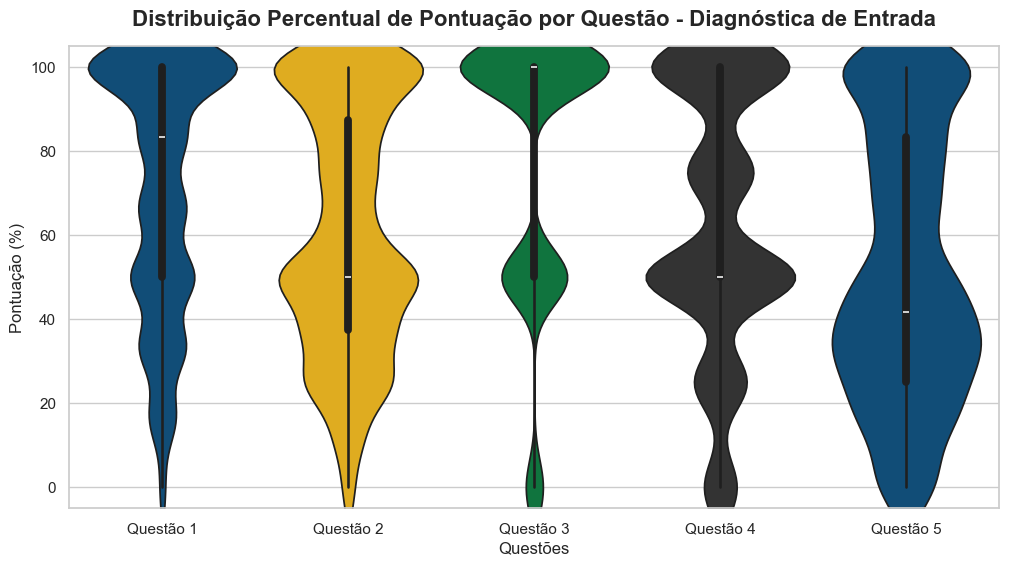

In [326]:
plt.figure(figsize=(12, 6))

# Usando as cores oficiais do PBA para manter o padrão
sns.violinplot(data=df_pedagogico[colunas_pct], palette=cores_pba[:len(colunas_pct)])

plt.title('Distribuição Percentual de Pontuação por Questão - Diagnóstica de Entrada', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Pontuação (%)', fontsize=12)
plt.xlabel('Questões', fontsize=12)
plt.xticks(ticks=range(5), labels=['Questão 1', 'Questão 2', 'Questão 3', 'Questão 4', 'Questão 5'])
plt.ylim(-5, 105)

# Salvando gráfico
nome_grafico_2 = '2_distribuicao_questoes_pct.png'
caminho_grafico_2 = os.path.join(dir_graficos, nome_grafico_2)

plt.savefig(caminho_grafico_2, dpi=300, bbox_inches='tight') # dpi=300 garante alta qualidade para relatórios/impressão
print(f"Gráfico salvo com sucesso em: {caminho_grafico_2}")
plt.show()


#### 4.3 Classificação Algorítmica das Questões
Utilizando a Teoria Clássica dos Testes associada ao **algoritmo K-Means**, agruparemos as questões em 3 níveis de dificuldade (Fácil, Intermediária e Difícil) baseando-nos puramente na média percentual de desempenho dos alfabetizandos.

In [327]:
# 1. Calculando a média percentual de cada questão
medias_questoes = df_pedagogico[colunas_pct].mean().to_frame(name='media_percentual')

# 2. Aplicando o algoritmo K-Means para criar 3 clusters (Fácil, Intermediária, Difícil)
kmeans = KMeans(n_clusters=3, random_state=42)
medias_questoes['cluster'] = kmeans.fit_predict(medias_questoes[['media_percentual']])

# 3. Mapeando os clusters para os rótulos de dificuldade
# O cluster com a maior média será o Fácil, o do meio Intermediário, e o menor Difícil.
medias_ordenadas = medias_questoes.groupby('cluster')['media_percentual'].mean().sort_values()

# Dicionário dinâmico para mapear o id do cluster para o nome correto
mapa_dificuldade = {
    medias_ordenadas.index[0]: 'Difícil',
    medias_ordenadas.index[1]: 'Intermediária',
    medias_ordenadas.index[2]: 'Fácil'
}

medias_questoes['classificacao_algoritmo'] = medias_questoes['cluster'].map(mapa_dificuldade)
medias_questoes = medias_questoes.sort_values(by='media_percentual', ascending=False).round(2)

print("Classificação gerada pelo algoritmo K-Means:")
display(medias_questoes[['media_percentual', 'classificacao_algoritmo']])

Classificação gerada pelo algoritmo K-Means:


,media_percentual,classificacao_algoritmo
forma_1_q3_pct,78.45,Fácil
forma_1_q1_pct,70.64,Intermediária
forma_1_q4_pct,62.74,Difícil
forma_1_q2_pct,61.03,Difícil
forma_1_q5_pct,51.99,Difícil


#### 4.3.1 Descobrindo o Agrupamento Natural (Método do Cotovelo)
Antes de definirmos a classificação em 3 níveis (Fácil, Intermediário, Difícil), vamos utilizar o **Método do Cotovelo** para observar como as questões se agrupam naturalmente com base em suas médias percentuais. Calcularemos a inércia do K-Means para diferentes quantidades de clusters ($k$).

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/2_distribuicao_questoes_pct.png


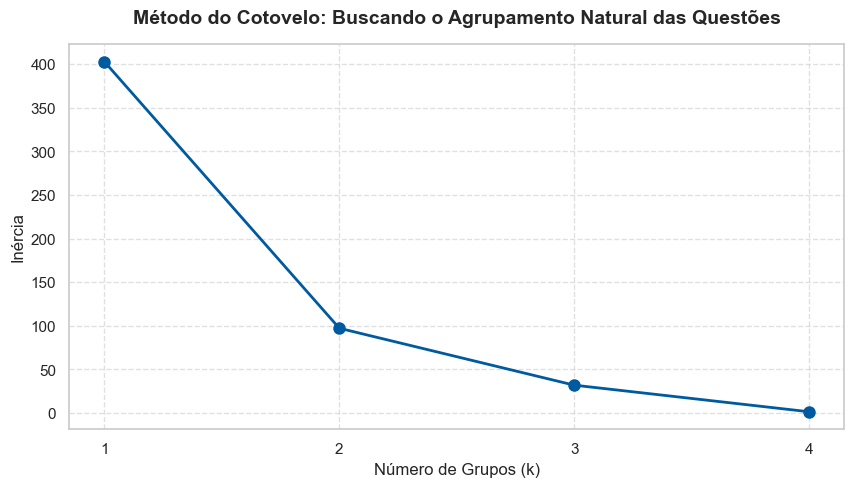

In [328]:
# Importando a biblioteca caso ainda não tenha importado
inercia = []
# Como temos apenas 5 questões, vamos testar k de 1 até 4
valores_k = range(1, 5)

for k in valores_k:
    # O n_init=10 é adicionado para evitar warnings em versões mais recentes do scikit-learn
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(medias_questoes[['media_percentual']])
    
    # inertia_ guarda a soma das distâncias quadradas dentro dos clusters
    inercia.append(kmeans_teste.inertia_)

# Plotando o gráfico do Método do Cotovelo
plt.figure(figsize=(10, 5))
plt.plot(valores_k, inercia, marker='o', linestyle='-', color='#005aa0', linewidth=2, markersize=8)

plt.title('Método do Cotovelo: Buscando o Agrupamento Natural das Questões', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Grupos (k)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.6)

# Salvando o gráfico
nome_grafico_3 = '3_metodo_cotovelo_questoes.png'
caminho_grafico_3 = os.path.join(dir_graficos, nome_grafico_3)

plt.savefig(caminho_grafico_3, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_2}")
plt.show()





In [329]:
# 1. Pegamos os valores centrais (centroides) que o algoritmo encontrou e os ordenamos
centroides = kmeans.cluster_centers_.flatten()
centroides_ordenados = np.sort(centroides)

# 2. Calculamos o ponto médio entre os centroides para achar as fronteiras (notas de corte)
corte_dificil_inter = (centroides_ordenados[0] + centroides_ordenados[1]) / 2
corte_inter_facil = (centroides_ordenados[1] + centroides_ordenados[2]) / 2

print("--- REGRAS DE CLASSIFICAÇÃO DO ALGORITMO ---")
print(f"O algoritmo considerou os seguintes limites baseados na distância matemática:")
print(f"-> DIFÍCIL: Médias abaixo de {corte_dificil_inter:.2f}%")
print(f"-> INTERMEDIÁRIA: Médias entre {corte_dificil_inter:.2f}% e {corte_inter_facil:.2f}%")
print(f"-> FÁCIL: Médias acima de {corte_inter_facil:.2f}%")

--- REGRAS DE CLASSIFICAÇÃO DO ALGORITMO ---
O algoritmo considerou os seguintes limites baseados na distância matemática:
-> DIFÍCIL: Médias abaixo de 64.61%
-> INTERMEDIÁRIA: Médias entre 64.61% e 74.54%
-> FÁCIL: Médias acima de 74.54%


#### 4.4 Comparação: Realidade Analítica vs. Parâmetro Estabelecido
Nesta etapa, cruzaremos os resultados obtidos pelo algoritmo (baseado no desempenho real dos alunos) com o grau de dificuldade originalmente planejado para a avaliação.

In [330]:
# ATENÇÃO: Substitua os valores abaixo pela classificação que você já possui
classificacao_estabelecida = {
    'forma_1_forma_1_q1_pct': 'Fácil',
    'forma_1_forma_1_q2_pct': 'Intermediária',
    'forma_1_forma_1_q3_pct': 'Intermediária',
    'forma_1_forma_1_q4_pct': 'Difícil',
    'forma_1_forma_1_q5_pct': 'Difícil'
}

# Adicionando a classificação estabelecida ao DataFrame
medias_questoes['classificacao_estabelecida'] = medias_questoes.index.map(classificacao_estabelecida)

# Criando flag para saber se o algoritmo e o teste estão alinhados
medias_questoes['alinhamento'] = medias_questoes['classificacao_algoritmo'] == medias_questoes['classificacao_estabelecida']

# Formatando a tabela para exibição final
tabela_comparativa = medias_questoes[['media_percentual', 'classificacao_estabelecida', 'classificacao_algoritmo', 'alinhamento']].copy()
tabela_comparativa.index = ['Questão 1', 'Questão 2', 'Questão 3', 'Questão 4', 'Questão 5'] # Ajuste na ordem se precisar
tabela_comparativa.columns = ['Média (%)', 'Dificuldade Planejada', 'Dificuldade Real (Algoritmo)', 'Alinhado?']

print("Comparativo Final de Dificuldade das Questões:")
display(tabela_comparativa)

# Opcional: Salvar a tabela comparativa em Excel para anexar ao relatório
caminho_comparativo = os.path.join(dir_graficos, '3_comparativo_dificuldade_questoes.xlsx')
tabela_comparativa.to_excel(caminho_comparativo)


Comparativo Final de Dificuldade das Questões:


,Média (%),Dificuldade Planejada,Dificuldade Real (Algoritmo),Alinhado?
Questão 1,78.45,NaN,Fácil,False
Questão 2,70.64,NaN,Intermediária,False
Questão 3,62.74,NaN,Difícil,False
Questão 4,61.03,NaN,Difícil,False
Questão 5,51.99,NaN,Difícil,False


## 5. Avaliação Pedagógica e Resultados do Diagnóstico Inicial

Este capítulo detalha os resultados obtidos através da aplicação da Formativa 1. De acordo com o **Termo de Referência do PBA SE 2026**, o monitoramento da rotina de alfabetização deve partir de uma base sólida de dados que identifique o nível de adesão ao que foi ensinado em sala durante os estudos da última unidade.

A análise a seguir foca:
- Entender a distribuição geral de turmas e alfabetizandos entre os municípios;
- Entender a distribuição geral dos alfabetizandos pelos níveis **N1 a N4**, permitindo que a coordenação pedagógica ajuste as aulas e as formações de acordo com a realidade de cada turma. 
- Entender a distribuição dos alfabetizandos pelos níveis **N1 a N4** para cada município;
- Entender a realidade de alfabetizandos na Formativa 1 que tiraram niveis **N3 ou N4** durante a atividade diagnóstica, buscando checar o verdadeiro nível de proficiencia desses alfabetizandos ou entender se houve interferência do auxílio do alfabetizador na determinação do nível de alfabetização inicial.

### 5.1 Cobertura Territorial: Turmas e Alunos por Município

Para o monitoramento da rotina de alfabetização, é essencial cruzar o número de turmas ativas com o volume de alunos. Esta análise permite identificar a densidade do programa em cada localidade e verificar a conformidade com as metas de atendimento.


In [331]:
# Configurações de estilo e paleta
sns.set_style("whitegrid", {'axes.grid' : False}) # Grid personalizado

# Consolidação de Dados por Município
# Criando um resumo por município a partir do df_turmas
resumo_municipios = df_turmas.groupby('municipio').agg(
    qtd_turmas=('turma', 'count'),
    total_alunos=('qtd_alfabetizandos', 'sum')
).sort_values(by='total_alunos', ascending=False).reset_index()

# Salvando arquivo
nome_do_arquivo_1 = 'turmas_e_alfabetizandos_por_municipio.xlsx'
caminho_excel_1 = os.path.join(dir_graficos, nome_do_arquivo_1)
resumo_municipios.to_excel(caminho_excel_1, index=False)

print(f"Planilha salva com sucesso em: {caminho_excel_1}")

# Imprimindo resultados
print(f'Quantidade de turmas no programa: {resumo_municipios["qtd_turmas"].sum()}')
print(f'Quantidade de municípios atendidos: {resumo_municipios.shape[0]}')
print(f'Quantidade de turmas com resultados de atividade diagnóstica: {df_pedagogico["turma"].nunique()}')
print(f'Quantidade de municipios com turmas com resultados de atividade diagnóstica: {df_pedagogico["municipio"].nunique()}')
print("Resumo de Distribuição por Município:")
display(resumo_municipios)


Planilha salva com sucesso em: graficos_relatorio_2.1.1/turmas_e_alfabetizandos_por_municipio.xlsx
Quantidade de turmas no programa: 138
Quantidade de municípios atendidos: 31
Quantidade de turmas com resultados de atividade diagnóstica: 137
Quantidade de municipios com turmas com resultados de atividade diagnóstica: 31
Resumo de Distribuição por Município:


,municipio,qtd_turmas,total_alunos
0,ARACAJU,18,334
1,LAGARTO,17,306
2,SIMÃO DIAS,13,244
3,PORTO DA FOLHA,10,236
4,ITABAIANA,9,220
5,MONTE ALEGRE DE SERGIPE,6,127
6,SÃO CRISTÓVÃO,7,124
7,ESTÂNCIA,6,104
8,POÇO VERDE,5,100
9,ITABAIANINHA,5,94


Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/4_numero_de_turmas_e_alunos_por_municipio.png


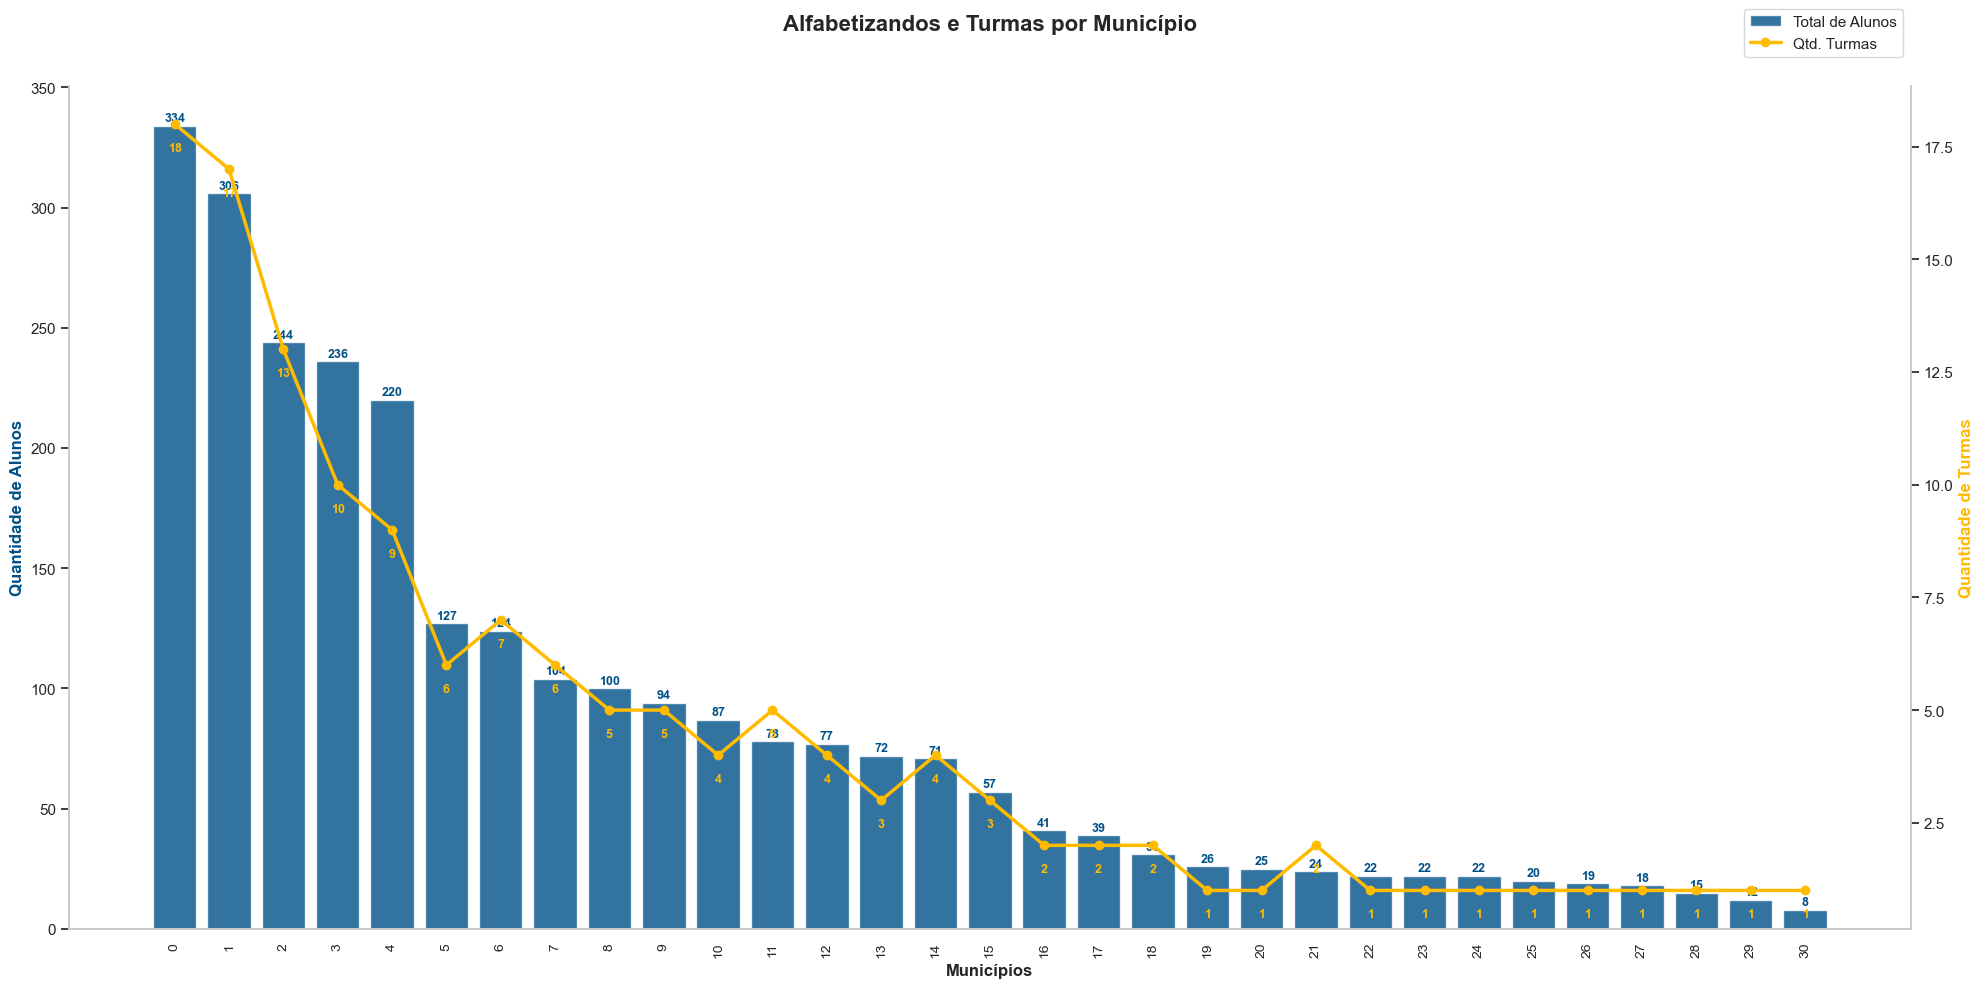

In [332]:
# Preparação dos dados para criação de gráfico de turmas e alfabetizandos(Garantindo que todos os municípios sejam incluídos)
resumo_completo = resumo_municipios.copy() # Usando o DF que criamos anteriormente
x_labels = resumo_completo.index

# Configuração do gráfico
fig, ax1 = plt.subplots(figsize=(20, 10)) # Aumentamos a largura para caber todos

# --- EIXO 1: ALUNOS (BARRAS) ---
barras = ax1.bar(x_labels, resumo_completo['total_alunos'], color="#005088", label='Total de Alunos', alpha=0.8)
ax1.set_ylabel('Quantidade de Alunos', color="#005088", fontsize=12, fontweight='bold')
ax1.set_xlabel('Municípios', fontsize=12, fontweight='bold')

# Rótulos das barras (Alunos) - No topo das barras
ax1.bar_label(barras, padding=1, color="#005088", fontweight='bold', fontsize=9)

# Configuração do Eixo X para mostrar TODOS os nomes
ax1.set_xticks(range(len(x_labels)))
ax1.set_xticklabels(x_labels, rotation=90, fontsize=10)

# --- EIXO 2: TURMAS (LINHA) ---
ax2 = ax1.twinx()
linha = ax2.plot(x_labels, resumo_completo['qtd_turmas'], color="#FFBB00", marker='o', 
                 linewidth=2.5, markersize=6, label='Qtd. Turmas')
ax2.set_ylabel('Quantidade de Turmas', color="#FFBB00", fontsize=12, fontweight='bold')

# Rótulos da linha (Turmas) - ABAIXO do ponto e na COR #FFBB00
for i, valor in enumerate(resumo_completo['qtd_turmas']):
    ax2.text(i, valor - 0.4, str(int(valor)), color="#FFBB00", 
             ha='center', va='top', fontweight='bold', fontsize=9)

# Unificando as legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', bbox_to_anchor=(1, 1.1))

plt.title('Alfabetizandos e Turmas por Município', fontsize=16, pad=40, fontweight='bold')
plt.tight_layout()
sns.despine(right=False)

# Salvando o gráfico em dir_graficos
nome_grafico_4 = '4_numero_de_turmas_e_alunos_por_municipio.png'
caminho_grafico_4 = os.path.join(dir_graficos, nome_grafico_4)

plt.savefig(caminho_grafico_4, dpi=300, bbox_inches='tight') # dpi=300 garante alta qualidade para relatórios/impressão
print(f"Gráfico salvo com sucesso em: {caminho_grafico_4}")
plt.show()


### 5.2 Níveis adesão ao conteúdo estudado (Formativa 1)

Para fins deste relatório, a classificação segue os critérios estabelecidos pela FGV DGPE:
* **N1:** Não reconhece as letras do alfabeto.
* **N2** Lê e registra algumas letras com ajuda, sem relação entre fala e escrita.
* **N3:** Reconhece algumas letras do alfabeto.
* **N4:** Identifica o número de sílabas de palavras com apoio.

Total de alunos que realizaram a Avaliação Formativa 1: 2575
Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/5_distribuicao_geral_forma_1.png


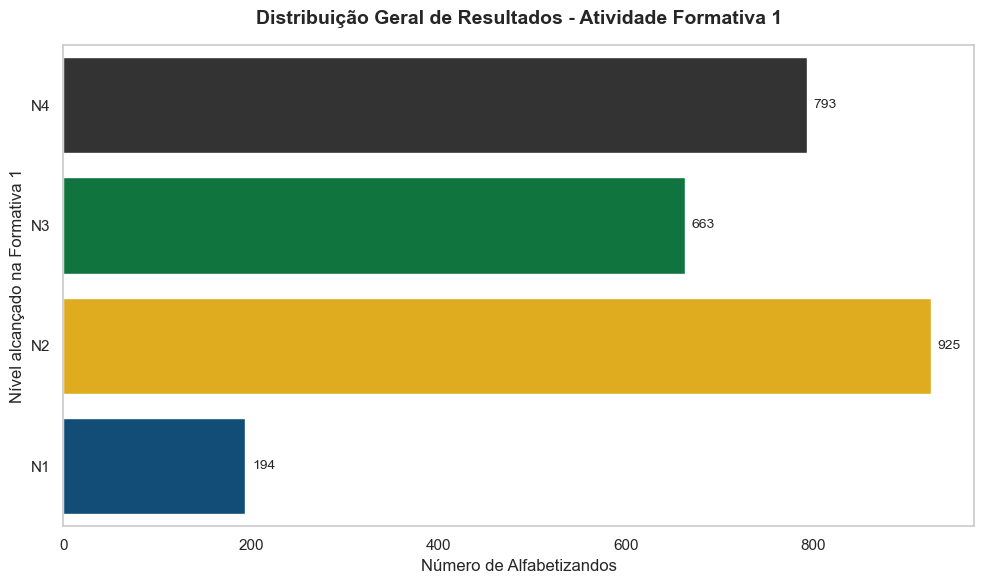

In [333]:
# 1. Filtrar apenas os alunos que realizaram a Formativa 1
df_formativa1 = df_pedagogico.dropna(subset=['forma_1_result_resum']).copy()

print(f"Total de alunos que realizaram a Avaliação Formativa 1: {df_formativa1.shape[0]}")

# 2. Configurar e criar o gráfico
plt.figure(figsize=(10, 6))
ordem_fixa = ['N4', 'N3', 'N2', 'N1']  # Ordem desejada dos níveis

sns.countplot(
    y='forma_1_result_resum', 
    data=df_formativa1, 
    order=ordem_fixa, 
    palette=cores_pba,
    hue='forma_1_result_resum', # Evitar warning da paleta
    legend=False
)

plt.title('Distribuição Geral de Resultados - Atividade Formativa 1', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Alfabetizandos', fontsize=12)
plt.ylabel('Nível alcançado na Formativa 1', fontsize=12)

# Adicionar os valores exatos em cada barra para ficar mais profissional
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points', fontsize=10)
    
# Salvando o gráfico
nome_grafico_5 = '5_distribuicao_geral_forma_1.png'
caminho_grafico_5 = os.path.join(dir_graficos, nome_grafico_5)

plt.savefig(caminho_grafico_5, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_5}")

plt.tight_layout()
plt.show()


### 5.3 Formativa 1 por Município (Geração de Gráficos Individuais)

Para subsidiar as equipes técnicas locais, automatizamos a geração de gráficos de desempenho para cada um dos municípios parceiros. 

**Processo de Automação:**
1. O código identifica todos os municípios únicos na base de dados.
2. Filtra os alfabetizandos ativos de cada localidade.
3. Gera um gráfico horizontal respeitando a identidade visual do PBA.
4. Salva o arquivo `.png` no diretório de saída (`dir_graficos`) para inclusão automática nos relatórios municipais.

In [334]:
# Lista de municípios únicos
municipios = sorted(df_pedagogico['municipio'].unique())

# Definimos a ordem fixa para que o gráfico SEMPRE reserve espaço para as 4 barras
# Isso evita que o gráfico "alargue" as barras quando um município tem apenas 1 ou 2 níveis
print(f"Iniciando a geração de gráficos padronizados para {len(municipios)} municípios...")

for muni in municipios:
    df_muni = df_formativa1[df_formativa1['municipio'] == muni]
    
    # Agrupar dados
    resultado_muni = df_muni.groupby(['forma_1_result_resum'], observed=False)['cpf'].count().reset_index()
    resultado_muni.columns = ['resultado_forma_1', 'numero_alfabetizandos']
    
    # Mantemos o figsize similar ao seu gráfico geral para proporção
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # --- AJUSTE DE ESPESSURA ---
    sns.barplot(
        data=resultado_muni, 
        x='numero_alfabetizandos', 
        y='resultado_forma_1', 
        palette=cores_pba,
        hue='resultado_forma_1', # Colorir a barra com base no resultado
        order=ordem_fixa, # ESSENCIAL: Garante que o eixo Y tenha sempre 4 posições
        height=0.8,       # FIXA A ESPESSURA: 0.8 é a largura padrão do Seaborn
        ax=ax
    )
    
    # Adicionar rótulos (Loop em todos os containers)
    for container in ax.containers:
        ax.bar_label(container, padding=10, fontweight='bold', color='#333333')
    
    # Títulos e Estética (Seguindo seu padrão)
    ax.set_title(f'Perfil de Entrada: {muni}', fontsize=14, pad=15, fontweight='bold', color="#005088")
    ax.set_xlabel('Quantidade de Alunos', fontsize=10)
    ax.set_ylabel('Nível', fontsize=10)
    
    # Ajuste de margem (1.4 garante espaço para o rótulo à direita)
    max_val = resultado_muni['numero_alfabetizandos'].max()
    ax.set_xlim(0, (max_val * 1.4) if max_val > 0 else 10)
    
    sns.despine()
    plt.tight_layout()
    
    # Salvando o arquivos no diretório dir_graficos
    nome_do_arquivo_3 = 'forma_1_resultados_por_municipio.xlsx'
    caminho_excel_3 = os.path.join(dir_graficos, nome_do_arquivo_3)
    resultado_muni.to_excel(caminho_excel_3, index=False)
    
    nome_arquivo = f"forma_1_{muni.lower().replace(' ', '_')}.png"
    caminho_salvamento = os.path.join(dir_graficos, nome_arquivo)
    
    plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
    plt.close(fig)

print(f"Sucesso! Gráficos com espessura padronizada salvos em: {dir_graficos}")


Iniciando a geração de gráficos padronizados para 31 municípios...
Sucesso! Gráficos com espessura padronizada salvos em: graficos_relatorio_2.1.1


### 5.4 Transição de Aprendizagem: O Desempenho dos Estudantes N3 e N4

Uma questão central para a nossa estratégia pedagógica é perceber o que acontece com os alunos que iniciam o programa com um nível mais avançado (Níveis N3 ou N4 na Avaliação Diagnóstica). Será que a Formativa 1 demonstrou que eles evoluíram, mantiveram o nível ou regrediram?

Abaixo, isolamos o grupo de alunos "N3 ou N4" da avaliação de entrada e cruzamos com os resultados que obtiveram agora na Formativa 1 através de uma **Matriz de Transição**.

Total de alunos (N3 ou N4 na entrada) que realizaram a Formativa 1: 932

Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/6_desempenho_na_formatica_1_apenas_alunos_n3_e_n4_na_entrada.png


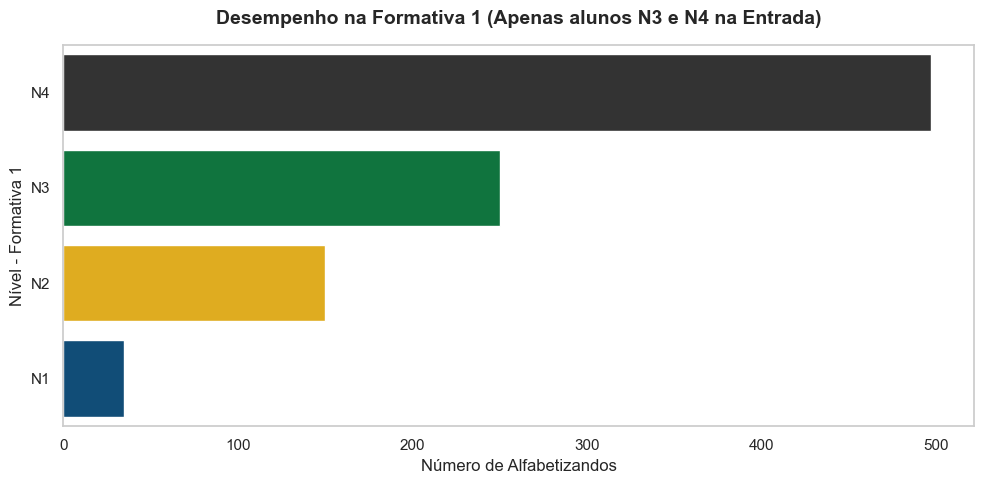


--- Matriz de Transição (Quantidade de Alunos): Diagnóstica de Entrada -> Formativa 1 ---


forma_1_result_resum,N1,N2,N3,N4,Total Geral
diag_entr_result,,,,,
N3 | Reconhece algumas letras do alfabeto,19,88,179,249,535
N4 | Identifica o número de sílabas de palavras com apoio,16,62,71,248,397
Total Geral,35,150,250,497,932


In [335]:
# 1. Filtrar alunos que tiraram N3 ou N4 na diagnóstica
n3_n4_diagnostica = df_pedagogico[df_pedagogico['diag_entr_result_resum'].str.contains('N3|N4', na=False, regex=True)].copy()

# 2. Remover quem não fez a formativa 1 dentro deste grupo
n3_n4_diagnostica = n3_n4_diagnostica.dropna(subset=['forma_1_result_resum'])

print(f"Total de alunos (N3 ou N4 na entrada) que realizaram a Formativa 1: {n3_n4_diagnostica.shape[0]}\n")

# 3. Plotar o desempenho específico destes alunos na Formativa 1
plt.figure(figsize=(10, 5))
sns.countplot(
    y='forma_1_result_resum', 
    data=n3_n4_diagnostica, 
    order=ordem_fixa, 
    palette=cores_pba,
    hue='forma_1_result_resum',
    legend=False
)
plt.title('Desempenho na Formativa 1 (Apenas alunos N3 e N4 na Entrada)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Alfabetizandos')
plt.ylabel('Nível - Formativa 1')

# Salvando o gráfico
nome_grafico_6 = '6_desempenho_na_formatica_1_apenas_alunos_n3_e_n4_na_entrada.png'
caminho_grafico_6 = os.path.join(dir_graficos, nome_grafico_6)

plt.savefig(caminho_grafico_6, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_6}")

plt.tight_layout()
plt.show()

# 4. Gerar a Matriz de Transição
print("\n--- Matriz de Transição (Quantidade de Alunos): Diagnóstica de Entrada -> Formativa 1 ---")
matriz_transicao = pd.crosstab(
    n3_n4_diagnostica['diag_entr_result'], 
    n3_n4_diagnostica['forma_1_result_resum'], 
    margins=True, 
    margins_name="Total Geral"
)

# Estilizando a tabela para destacar os números com cores
cm = sns.light_palette("purple", as_cmap=True)
tabela_estilizada = matriz_transicao.style.background_gradient(cmap=cm)

display(tabela_estilizada)


### 5.5 Cálculo do Índice de Progressão de Aprendizagem (IPA) - Formativa 1

Com os relatórios de notas consolidados, vamos calcular o **IPA** para a Formativa 1. Diferente de uma média simples, o IPA isola o desempenho do alfabetizando em cada prática de linguagem e aplica a regra de progressão contínua na Zona de Desenvolvimento Proximal (ZPD).

A fórmula fundamental de consolidação do sub-nível é:
$$IPA_{1,p} = \max\left(IPA_{0,p}, 1 \times S_{1,p}\right)$$

**Passos executados neste bloco:**
1. **Mapeamento de Questões:** Somamos os acertos agrupando pelas práticas (Oralidade e Leitura, Produção Escrita e Análise Linguística) de acordo com os descritores avaliados em cada questão da F1.
2. **Cálculo do Percentual ($S$):** Dividimos a soma obtida pelo teto máximo de cada prática.
3. **Ponderação Global:** Consolidamos o IPA Global atribuindo **45%** para Escrita, **40%** para Leitura e **15%** para Análise Linguística.
4. **Classificação:** Categorizamos o resultado em 4 níveis pedagógicos com bandas flexíveis para absorver pequenas margens de erro.

In [336]:
# ATENÇÃO: Substitua 'df_formativa1' pelo nome da variável do DataFrame onde você carregou o arquivo 'relatorios_turmas_formativa_1'
# E ajuste 'forma_1_q1', 'forma_1_q2', etc., para o nome exato das colunas de notas na sua base.

# 1. Mapear as notas das questões para suas respectivas Práticas de Linguagem
# OL e PE são avaliadas em todas as questões da F1. AL apenas na forma_1_q2 e forma_1_q5.
df_formativa1['pontuacao_ol'] = df_formativa1['forma_1_q1'] + df_formativa1['forma_1_q2'] + df_formativa1['forma_1_q3'] + df_formativa1['forma_1_q4'] + df_formativa1['forma_1_q5']
df_formativa1['pontuacao_pe'] = df_formativa1['forma_1_q1'] + df_formativa1['forma_1_q2'] + df_formativa1['forma_1_q3'] + df_formativa1['forma_1_q4'] + df_formativa1['forma_1_q5']
df_formativa1['pontuacao_al'] = df_formativa1['forma_1_q2'] + df_formativa1['forma_1_q5']

# 2. Definir os Parâmetros (Tetos Máximos da F1 e Pesos Preditivos)
tetos_f1 = {'ol': 32, 'pe': 32, 'al': 20}
pesos = {'pe': 0.45, 'ol': 0.40, 'al': 0.15}

# Inicializar o IPA Diagnóstica (Nível Base = 1.0) caso não exista na base consolidada
for pratica in ['ol', 'pe', 'al']:
    col_name = f'ipa_diagnostica_{pratica}'
    if col_name not in df_formativa1.columns:
        df_formativa1[col_name] = 1.0

# 3. Calcular o Percentual de Acerto (S) na Formativa 1
df_formativa1['s_ol_f1'] = df_formativa1['pontuacao_ol'] / tetos_f1['ol']
df_formativa1['s_pe_f1'] = df_formativa1['pontuacao_pe'] / tetos_f1['pe']
df_formativa1['s_al_f1'] = df_formativa1['pontuacao_al'] / tetos_f1['al']

# 4. Calcular o Sub-nível de Cada Prática (IPA por Prática)
df_formativa1['ipa_ol_f1'] = np.maximum(df_formativa1['ipa_diagnostica_ol'], 1 * df_formativa1['s_ol_f1'])
df_formativa1['ipa_pe_f1'] = np.maximum(df_formativa1['ipa_diagnostica_pe'], 1 * df_formativa1['s_pe_f1'])
df_formativa1['ipa_al_f1'] = np.maximum(df_formativa1['ipa_diagnostica_al'], 1 * df_formativa1['s_al_f1'])

# 5. Calcular o IPA Global da Formativa 1 (Índice Composto)
df_formativa1['ipa_global_f1'] = (
    (pesos['pe'] * df_formativa1['ipa_pe_f1']) + 
    (pesos['ol'] * df_formativa1['ipa_ol_f1']) + 
    (pesos['al'] * df_formativa1['ipa_al_f1'])
).round(2)

# 6. Classificação Pedagógica utilizando os Thresholds Flexíveis
limites_ajustados = [0, 1.49, 2.49, 3.49, 4.01]
rotulos = ['N1', 'N2', 'N3', 'N4']

df_formativa1['classificacao_ipa'] = pd.cut(
    df_formativa1['ipa_global_f1'], 
    bins=limites_ajustados, 
    labels=rotulos, 
    right=True
)

# Ordenando níveis de classificação
df_formativa1['classificacao_ipa'] = pd.Categorical(
        df_formativa1['classificacao_ipa'], 
        categories=['N1', 'N2', 'N3', 'N4'], 
        ordered=True
    )

# Exibir os resultados finais isolando as colunas de interesse
colunas_visualizacao = ['pontuacao_ol', 'pontuacao_pe', 'pontuacao_al', 'ipa_global_f1', 'classificacao_ipa']
display(df_formativa1[colunas_visualizacao].head(10))


,pontuacao_ol,pontuacao_pe,pontuacao_al,ipa_global_f1,classificacao_ipa
0,30.0,30.0,20.0,1.0,N1
1,31.0,31.0,19.0,1.0,N1
2,32.0,32.0,20.0,1.0,N1
4,31.0,31.0,19.0,1.0,N1
5,31.0,31.0,19.0,1.0,N1
6,30.0,30.0,20.0,1.0,N1
7,32.0,32.0,20.0,1.0,N1
8,29.0,29.0,19.0,1.0,N1
10,30.0,30.0,18.0,1.0,N1
11,32.0,32.0,20.0,1.0,N1


Gráfico salvo com sucesso em: graficos_relatorio_2.1.1/7_ipa_formativa_1_geral.png


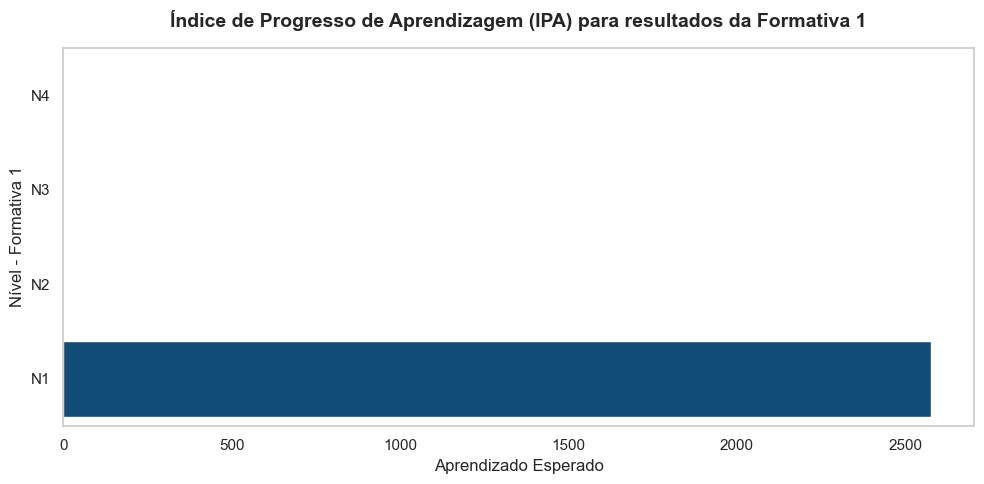

In [337]:
# Dicionário de Níveis para IPA
dicionario_nivel_ipa = {
    'N1': 'Iniciante',
    'N2': 'Em desenvolvimento',
    'N3': 'Alfabetizado(a)',
    'N4': 'Alfabetização avançada',
}

# Plotar o desempenho específico destes alunos na Formativa 1
plt.figure(figsize=(10, 5))
sns.countplot(
    y='classificacao_ipa', 
    data=df_formativa1, 
    order=ordem_fixa,
    palette=cores_pba,
    hue='classificacao_ipa',
    height=0.8,       # FIXA A ESPESSURA: 0.8 é a largura padrão do Seaborn
    legend=False
)
plt.title('Índice de Progresso de Aprendizagem (IPA) para resultados da Formativa 1', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Aprendizado Esperado')
plt.ylabel('Nível - Formativa 1')

# Salvando o gráfico
nome_grafico_7 = '7_ipa_formativa_1_geral.png'
caminho_grafico_7 = os.path.join(dir_graficos, nome_grafico_7)

plt.savefig(caminho_grafico_7, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_7}")

plt.tight_layout()
plt.show()


## 6. Monitoramento de Metas de Enturmação (Conformidade com o TR)

O Termo de Referência do PBA SE 2026 estipula limites para a formação das turmas, visando garantir a qualidade pedagógica e a otimização dos recursos. 

**Parâmetros Analisados:**
* **Limite Mínimo:** 14 alunos (referência para zona urbana).
* **Limite Máximo:** 27 alunos por turma.

Nesta seção, avaliamos a média de alfabetizandos por turma em cada município parceiro. Municípios fora desta faixa exigirão justificativas técnicas (ex: turmas em áreas rurais de difícil acesso, que permitem mínimo de 7 alunos) ou readequação de enturmação.

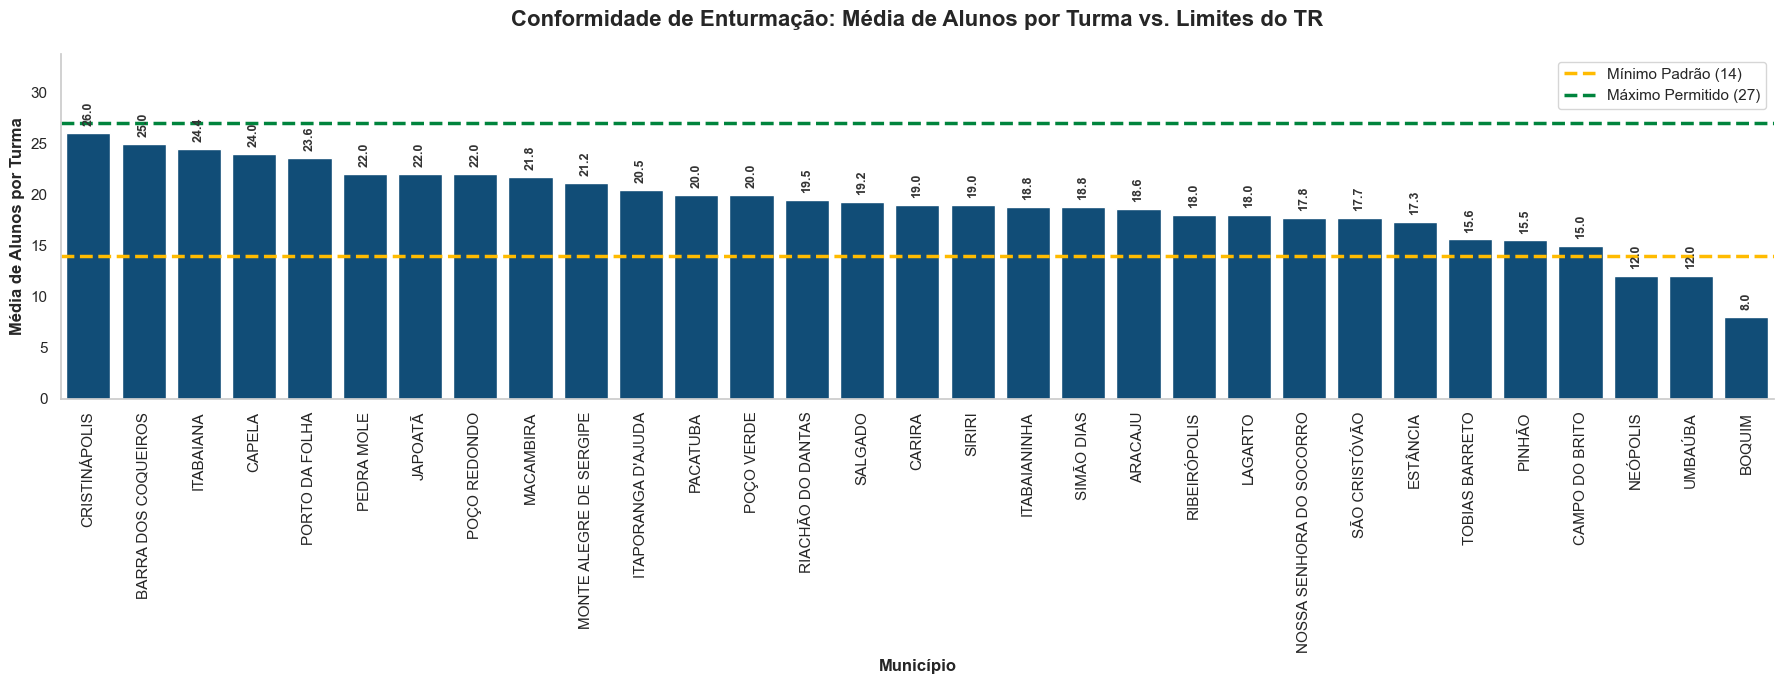

Gráfico de metas de enturmação gerado e salvo com sucesso.


In [338]:
# Agrupamento e cálculo da média de alunos por turma por município
resumo_metas = df_turmas.groupby('municipio', observed=True).agg(
    total_turmas=('turma', 'count'),
    media_alunos_turma=('qtd_alfabetizandos', 'mean')
).reset_index()

# Ordenando do maior para o menor para facilitar a visualização
resumo_metas = resumo_metas.sort_values('media_alunos_turma', ascending=False)

# Configuração do Gráfico
fig, ax = plt.subplots(figsize=(18, 7))

# Usaremos a cor Azul (#005088) como padrão
sns.barplot(
    data=resumo_metas, 
    x='municipio', 
    y='media_alunos_turma', 
    color=cores_pba[0], 
    ax=ax
)

# Adicionando as Linhas de Meta do TR
ax.axhline(14, color=cores_pba[1], linestyle='--', linewidth=2.5, label='Mínimo Padrão (14)') # Amarelo
ax.axhline(27, color=cores_pba[2], linestyle='--', linewidth=2.5, label='Máximo Permitido (27)') # Verde

# Adicionando os Rótulos de Dados nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold', color='#333333', fontsize=9, rotation=90)

# Ajustes Estéticos
ax.set_title('Conformidade de Enturmação: Média de Alunos por Turma vs. Limites do TR', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=12, fontweight='bold')
ax.set_ylabel('Média de Alunos por Turma', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Ajuste do limite Y para não cortar os rótulos
ax.set_ylim(0, resumo_metas['media_alunos_turma'].max() * 1.3)

ax.legend(loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()

# Salvando o Gráfico
nome_grafico_8 = '8_metas_enturmacao_municipio.png'
caminho_grafico_8 = os.path.join(dir_graficos, nome_grafico_8)
plt.savefig(caminho_grafico_8, dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de metas de enturmação gerado e salvo com sucesso.")


## 7. Monitoramento de Frequência e Risco de Evasão

A retenção do alfabetizando é um dos maiores desafios da EJA (Educação de Jovens e Adultos). O monitoramento da frequência é o indicador antecedente primário para o risco de evasão.

**Critério de Análise:**
* O índice mínimo de aceitação padrão em programas educacionais do estado costuma ser de **75% de frequência**. 
* Abaixo desse limite, a coordenação local deve acionar a estratégia de busca ativa.

*Nota: A taxa é calculada dividindo o número de presenças computadas pela quantidade de aulas dadas na turma até o momento do snapshot.*

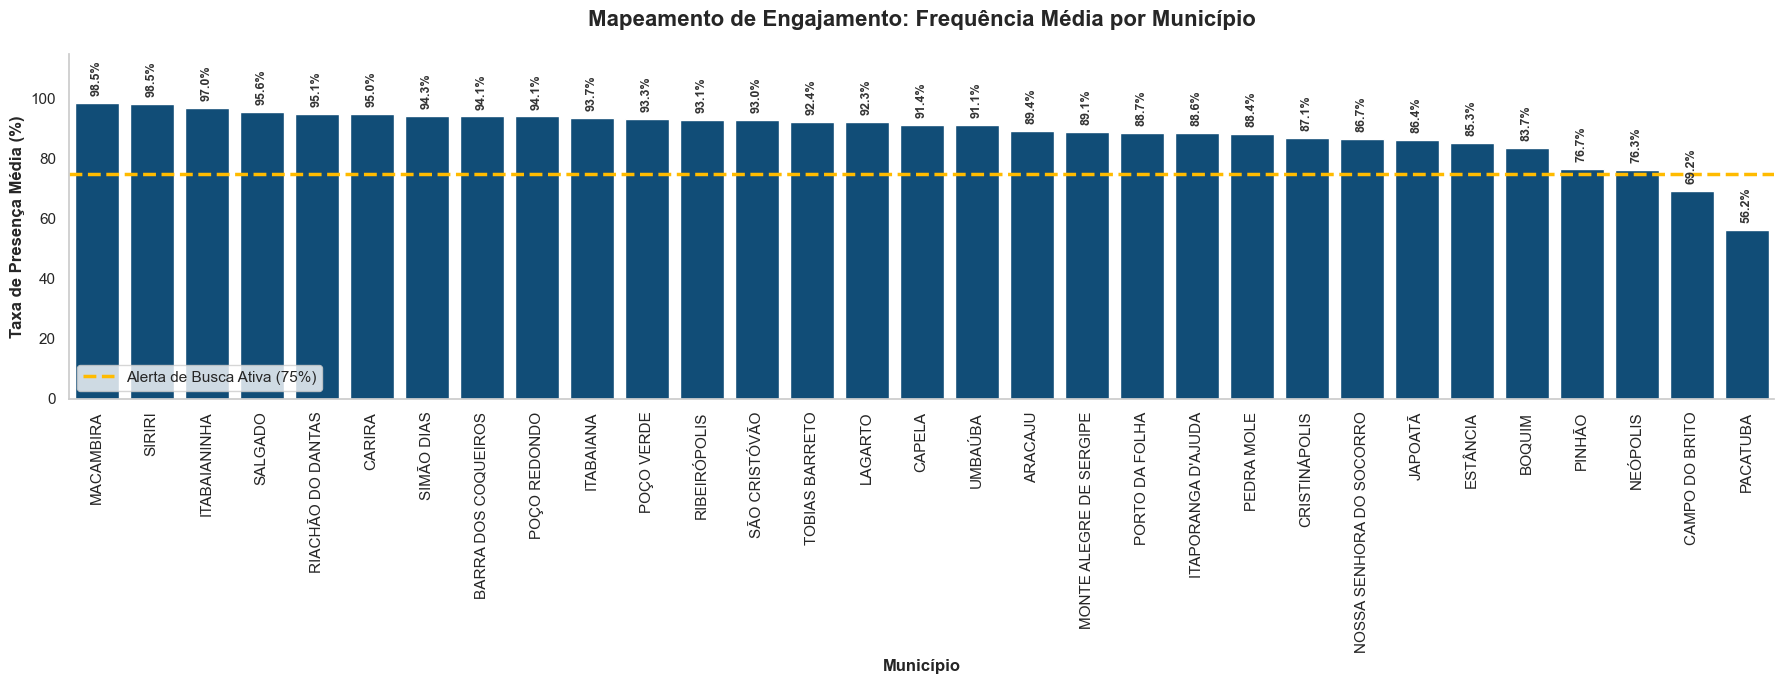

ALERTA EXECUTIVO:
Total de alunos com frequência abaixo de 75%: 264 (10.0% da amostra ativa).
Recomenda-se exportar a lista nominal destes alfabetizandos para os coordenadores locais.


In [339]:
# Tratamento e Cálculo da Taxa de Frequência
# Usamos np.where para evitar erro de divisão por zero caso haja turmas recém-criadas com 0 aulas dadas
df_pedagogico['taxa_frequencia'] = np.where(
    df_pedagogico['qtd_aulas_dadas_turma'] > 0,
    (df_pedagogico['qtd_presenca_alfabetizando'] / df_pedagogico['qtd_aulas_dadas_turma']) * 100,
    0
)

# Agrupamento por município para ver a frequência média
freq_muni = df_pedagogico.groupby('municipio', observed=True)['taxa_frequencia'].mean().reset_index()
freq_muni = freq_muni.sort_values('taxa_frequencia', ascending=False)

# Configuração do Gráfico
fig, ax = plt.subplots(figsize=(18, 7))

# Gráfico de barras na cor Azul institucional
sns.barplot(
    data=freq_muni, 
    x='municipio', 
    y='taxa_frequencia', 
    color=cores_pba[0], 
    ax=ax
)

# Linha de Alerta de Frequência (75%)
ax.axhline(75, color=cores_pba[1], linestyle='--', linewidth=2.5, label='Alerta de Busca Ativa (75%)') # Amarelo

# Adicionando os Rótulos de Dados
for container in ax.containers:
    # Usamos fmt='%.1f%%' para adicionar o símbolo de porcentagem no gráfico
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold', color='#333333', fontsize=9, rotation=90)

# Ajustes Estéticos
ax.set_title('Mapeamento de Engajamento: Frequência Média por Município', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Presença Média (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Forçamos o eixo Y a ir até 115 para caber bem os rótulos de 100%
ax.set_ylim(0, 115) 

ax.legend(loc='lower left', frameon=True)
sns.despine()
plt.tight_layout()

# Salvando o Gráfico
nome_grafico_9 = ('9_frequencia_media_municipio.png')
caminho_grafico_9 = os.path.join(dir_graficos, nome_grafico_9)
plt.savefig(caminho_grafico_9, dpi=300, bbox_inches='tight')
plt.show()

# Extração Executiva: Contagem de Alunos Críticos
alunos_risco = df_pedagogico[df_pedagogico['taxa_frequencia'] < 75].shape[0]
percentual_risco = (alunos_risco / len(df_pedagogico)) * 100

print(f"ALERTA EXECUTIVO:")
print(f"Total de alunos com frequência abaixo de 75%: {alunos_risco} ({percentual_risco:.1f}% da amostra ativa).")
print("Recomenda-se exportar a lista nominal destes alfabetizandos para os coordenadores locais.")
